# Data Mining - Cluster Analysis for Mixed Data

**Nama Kelompok:**
- Daris Ikhwana Khoir Suhaya (215)
- Kevin Febrian Widhiarta (025)
- Muhammad Tyas Subianto (077)
- Bimasena (214)

Pada Tugas kali ini, kita akan melakukan Cluster Analysis pada Mixed Data menggunakan dataset Bank Marketing dari UCI Machine Learning Repository. Dataset ini sangat representatif karena mengandung campuran variabel numerik (seperti usia, saldo rekening, durasi panggilan) dan variabel kategorik (seperti jenis pekerjaan, status pernikahan, pendidikan).

Link Dataset:https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

### Variansi Dataset
bank-full.csv: seluruh data (45.211 baris), terurut berdasarkan waktu (Mei 2008 – November 2010)

bank.csv: sampel 10% (4.521 baris), cocok untuk eksperimen ringan

### Data Summary

Jumlah data: 45.211 (full) / 4.521 (sample)

Jumlah fitur: 16

Missing values: tidak ada


### Client Information
age: usia (numerik)

job: jenis pekerjaan (kategorikal)

marital: status pernikahan

education: tingkat pendidikan

default: memiliki kredit macet (yes/no)

balance: saldo tahunan rata-rata (euro)

housing: memiliki kredit rumah (yes/no)

loan: memiliki pinjaman pribadi (yes/no)

### Contact Information

contact: jenis komunikasi

day: hari kontak terakhir

month: bulan kontak

duration: durasi kontak (detik)

### Campaign Information

campaign: jumlah kontak selama kampanye

pdays: hari sejak kontak sebelumnya (-1 jika belum pernah)

previous: jumlah kontak sebelumnya

poutcome: hasil kampanye sebelumnya

In [26]:
%pip install kmodes gower prince

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. Load dataset

In [29]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [31]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 2. Drop Target

In [32]:
df = df.drop(columns=['y'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown


## 3. Handling Missing Value

In [33]:
print('Jumlah missing value per kolom:')
print(df.isnull().sum())

Jumlah missing value per kolom:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


Karena disini tidak terdapat Missing value pada dataset kita, maka kita bisa lanjut langsung ke tahapan berikutnya

In [34]:
# Pisahkan kolom numerik dan kategorik
colnum = list(df.select_dtypes(exclude=['object']).columns)
colcat_names = list(df.select_dtypes(include=['object']).columns)

print('Kolom Numerik:', colnum)
print('Kolom Kategorik:', colcat_names)

Kolom Numerik: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kolom Kategorik: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 4. Exploratory Data Analysis (EDA)

Sebelum melakukan clustering, penting untuk memahami distribusi dan karakteristik data. EDA membantu kita mengetahui:
- Apakah data terdistribusi normal atau skewed?
- Seberapa beragam nilai kategorik?
- Apakah ada outlier yang signifikan?

Pemahaman ini penting karena akan memengaruhi interpretasi hasil klaster nantinya.

### Distribusi usia nasabah

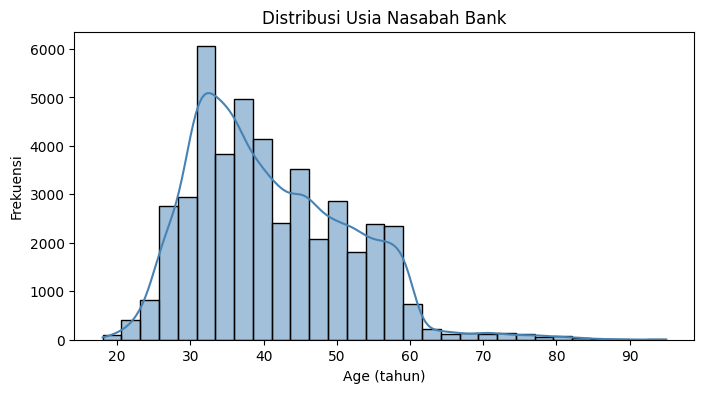

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], kde=True, bins=30, color='steelblue')
plt.title('Distribusi Usia Nasabah Bank')
plt.xlabel('Age (tahun)')
plt.ylabel('Frekuensi')
plt.show()

Rata-rata usia dari data tersebut adalah 40.9 tahun dengan Median atau nilai tengah 39 tahun.
Distribusi usia nasabah bank cenderung right-skewed

### Distribusi saldo rekening (balance)

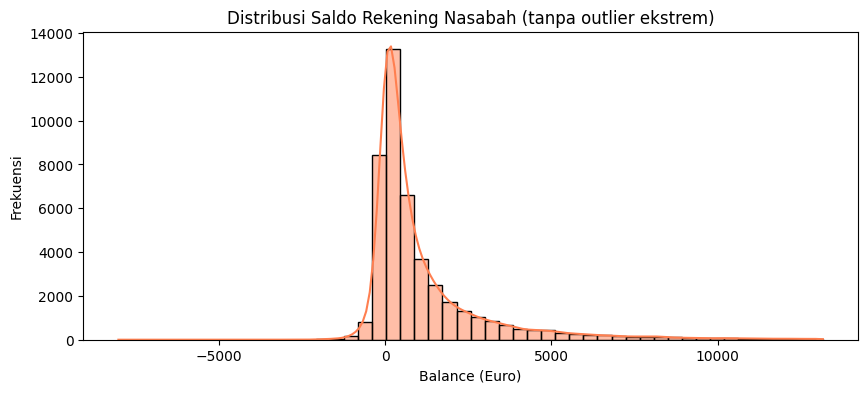

Median saldo: €448
Nasabah dengan saldo negatif: 3766 orang


In [36]:
plt.figure(figsize=(10,4))
balance_99 = df[df['balance'] < df['balance'].quantile(0.99)]['balance']
sns.histplot(balance_99, kde=True, bins=50, color='coral')
plt.title('Distribusi Saldo Rekening Nasabah (tanpa outlier ekstrem)')
plt.xlabel('Balance (Euro)')
plt.ylabel('Frekuensi')
plt.show()

print(f'Median saldo: €{df["balance"].median():.0f}')
print(f'Nasabah dengan saldo negatif: {(df["balance"] < 0).sum()} orang')

Median atau nilai tengah dari saldo pada data adalah €448.
Distribusi saldo rekening nasabah bank cenderung right-skewed dengan nasabah yang memiliki saldo negatif sebanyak 3766 orang.

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\1487502088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='housing', ax=axes[0], palette='Blues')
C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\1487502088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='loan', ax=axes[1], palette='Greens')


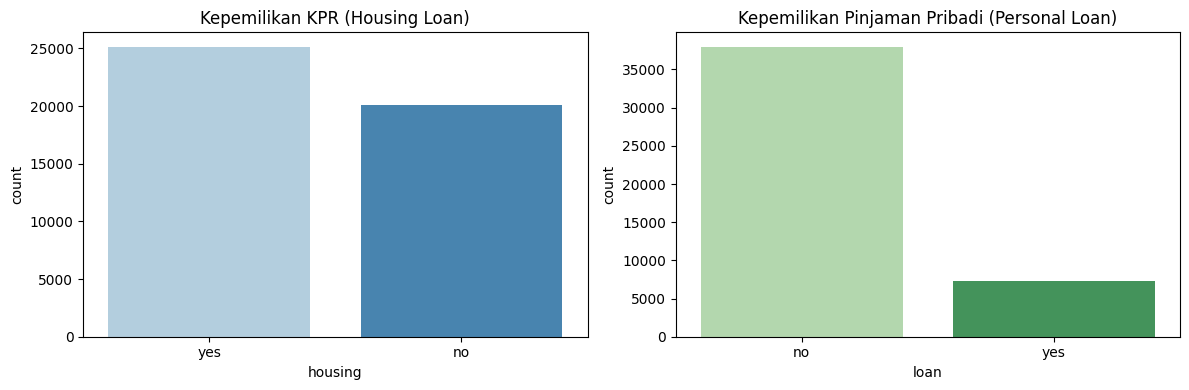

In [37]:
fig, axes = plt.subplots(ncols=2, figsize=(12,4))
sns.countplot(df, x='housing', ax=axes[0], palette='Blues')
axes[0].set_title('Kepemilikan KPR (Housing Loan)')
sns.countplot(df, x='loan', ax=axes[1], palette='Greens')
axes[1].set_title('Kepemilikan Pinjaman Pribadi (Personal Loan)')
plt.tight_layout()
plt.show()

Jumlah orang yang memiliki KPR "yes" sekitar 25.000, sedangkan yang tidak memiliki KPR (“no”) sekitar 20.000. Artinya, lebih banyak orang memiliki KPR dibanding yang tidak. Ini menunjukkan kepemilikan rumah dengan kredit cukup umum.

Yang tidak memiliki pinjaman (“no”) sekitar 38.000. Sedangkan yang memiliki pinjaman (“yes”) hanya sekitar 7.000–8.000. Artinya, sebagian besar orang tidak mengambil pinjaman pribadi.

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\3796010533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='month', order=month_order, palette='Blues_d')


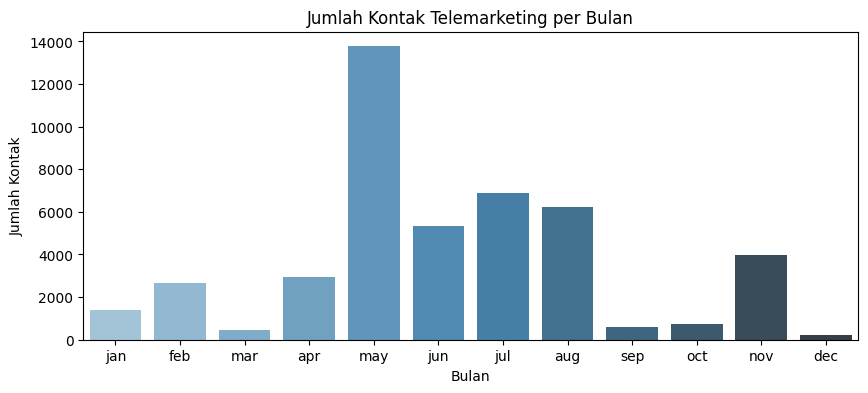

In [38]:
plt.figure(figsize=(10,4))
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
sns.countplot(df, x='month', order=month_order, palette='Blues_d')
plt.title('Jumlah Kontak Telemarketing per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kontak')
plt.show()

## 5. K-Prototypes Clustering


In [39]:
# Identifikasi indeks kolom kategorik untuk KPrototypes
colcat_names = list(df.select_dtypes(include=['object']).columns)
colcat = [list(df.columns).index(col) for col in colcat_names]

print('Kolom kategorik:', colcat_names)
print('Indeks kolom kategorik:', colcat)

Kolom kategorik: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Indeks kolom kategorik: [1, 2, 3, 4, 6, 7, 8, 10, 15]


In [40]:
# Daftar kolom numerik
colnum = list(df.select_dtypes(exclude=['object']).columns)
print('Kolom numerik:', colnum)
print(f'Total: {len(colnum)} kolom numerik, {len(colcat_names)} kolom kategorik')

Kolom numerik: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Total: 7 kolom numerik, 9 kolom kategorik


### Scaling data numerik menggunakan StandardScaler

In [41]:
df_scaled = df.copy()
scaler = StandardScaler()
df_scaled[colnum] = scaler.fit_transform(df[colnum])

print('Data setelah scaling:')
print(df_scaled.head())

Data setelah scaling:
        age           job  marital  education default   balance housing loan  \
0  1.606965    management  married   tertiary      no  0.256419     yes   no   
1  0.288529    technician   single  secondary      no -0.437895     yes   no   
2 -0.747384  entrepreneur  married  secondary      no -0.446762     yes  yes   
3  0.571051   blue-collar  married    unknown      no  0.047205     yes   no   
4 -0.747384       unknown   single    unknown      no -0.447091      no   no   

   contact       day month  duration  campaign     pdays  previous poutcome  
0  unknown -1.298476   may  0.011016 -0.569351 -0.411453  -0.25194  unknown  
1  unknown -1.298476   may -0.416127 -0.569351 -0.411453  -0.25194  unknown  
2  unknown -1.298476   may -0.707361 -0.569351 -0.411453  -0.25194  unknown  
3  unknown -1.298476   may -0.645231 -0.569351 -0.411453  -0.25194  unknown  
4  unknown -1.298476   may -0.233620 -0.569351 -0.411453  -0.25194  unknown  


In [42]:
from kmodes.kprototypes import KPrototypes

df_sample = df_scaled.sample(n=3000, random_state=42).reset_index(drop=True)

costs = []
n_clusters = []
clusters_assigned = []

for i in range(2, 10):
    kproto = KPrototypes(n_clusters=i, random_state=10, init='Huang', n_init=1, verbose=0)
    clusters = kproto.fit_predict(df_sample, categorical=colcat)
    costs.append(kproto.cost_)
    n_clusters.append(i)
    clusters_assigned.append(clusters)
    print(f'K={i}, Cost={kproto.cost_:.2f}')

K=2, Cost=23150.57
K=3, Cost=20102.62
K=4, Cost=18814.13
K=5, Cost=17314.14
K=6, Cost=15507.08
K=7, Cost=15339.89
K=8, Cost=14077.09
K=9, Cost=12730.42


Disini kita mencoba K dari 2 sampai 9 dan mencatat nilai cost (distortion) untuk menentukan K Optimal menggunakan Elbow Method, kita gunakan subset data yang di random sebanyak 3000 data saja agar proses elbow lebih cepat.

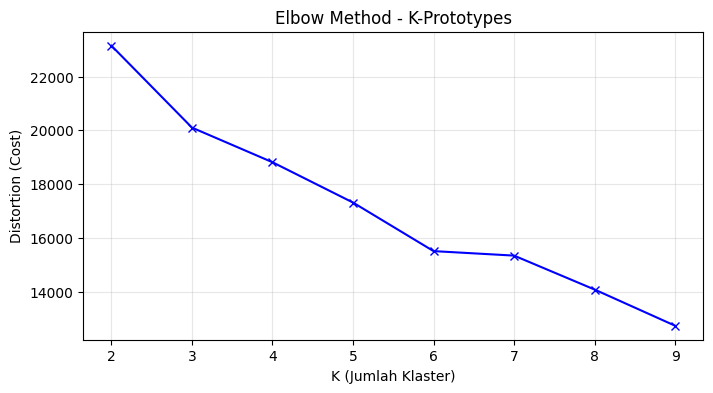

In [43]:
plt.figure(figsize=(8,4))
plt.plot(n_clusters, costs, 'bx-')
plt.ylabel('Distortion (Cost)')
plt.xlabel('K (Jumlah Klaster)')
plt.title('Elbow Method - K-Prototypes')
plt.xticks(n_clusters)
plt.grid(True, alpha=0.3)
plt.show()

Dari gambar dapat dilihat bahwa K yang optimal yaitu K = 3 atau K = 6, disini kita akan pilih K = 3 agar lebih mudah diinterpretasikan berdasarkan konteks dataset yang kita miliki.

In [44]:
kproto = KPrototypes(n_clusters=3, random_state=10, init='Huang', n_init=1, verbose=1)
clusters = kproto.fit_predict(df_scaled, categorical=colcat)

print('\nDistribusi Klaster')
unique, counts = np.unique(clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Klaster {u}: {c} nasabah ({c/len(clusters)*100:.1f}%)')

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 8037, ncost: 323449.98387315404
Run: 1, iteration: 2/100, moves: 4748, ncost: 314966.9689036916
Run: 1, iteration: 3/100, moves: 1356, ncost: 314235.6338477045
Run: 1, iteration: 4/100, moves: 444, ncost: 314204.47728215455
Run: 1, iteration: 5/100, moves: 240, ncost: 314191.97390146164
Run: 1, iteration: 6/100, moves: 154, ncost: 314183.20141578466
Run: 1, iteration: 7/100, moves: 163, ncost: 314163.72367725556
Run: 1, iteration: 8/100, moves: 336, ncost: 314096.9749521669
Run: 1, iteration: 9/100, moves: 457, ncost: 313990.5617284577
Run: 1, iteration: 10/100, moves: 472, ncost: 313906.7627103578
Run: 1, iteration: 11/100, moves: 427, ncost: 313859.0100801825
Run: 1, iteration: 12/100, moves: 315, ncost: 313839.45538992353
Run: 1, iteration: 13/100, moves: 191, ncost: 313831.8639617471
Run: 1, iteration: 14/100, moves: 122, ncost: 313828.76500357804
Run: 1, iteration: 15/1

Disini kita lakukan iterasi sebanyak 100 kali dengan K = 3 berdasarkan hasil elbow method yang sudah kita lakukan sebelumnya. Didapatkan pergerakan yang semakin berkurang tiap makin banyak iterasi dimulai dari 8037 hingga ke 0 pada iterasi 20/100.

Didapatkan Distribusi Klaster degan Klaster ke 2 paling besar, yakni 52% kemudian disusul klaster 0 sebesar 33% dan klaster 2 sebesar 14.5%

In [45]:
# Menyimpan label klaster ke dataframe asli
df['cluster'] = kproto.labels_
df_scaled['cluster'] = kproto.labels_

### Visualisasi distribusi fitur NUMERIK per klaster menggunakan boxplot

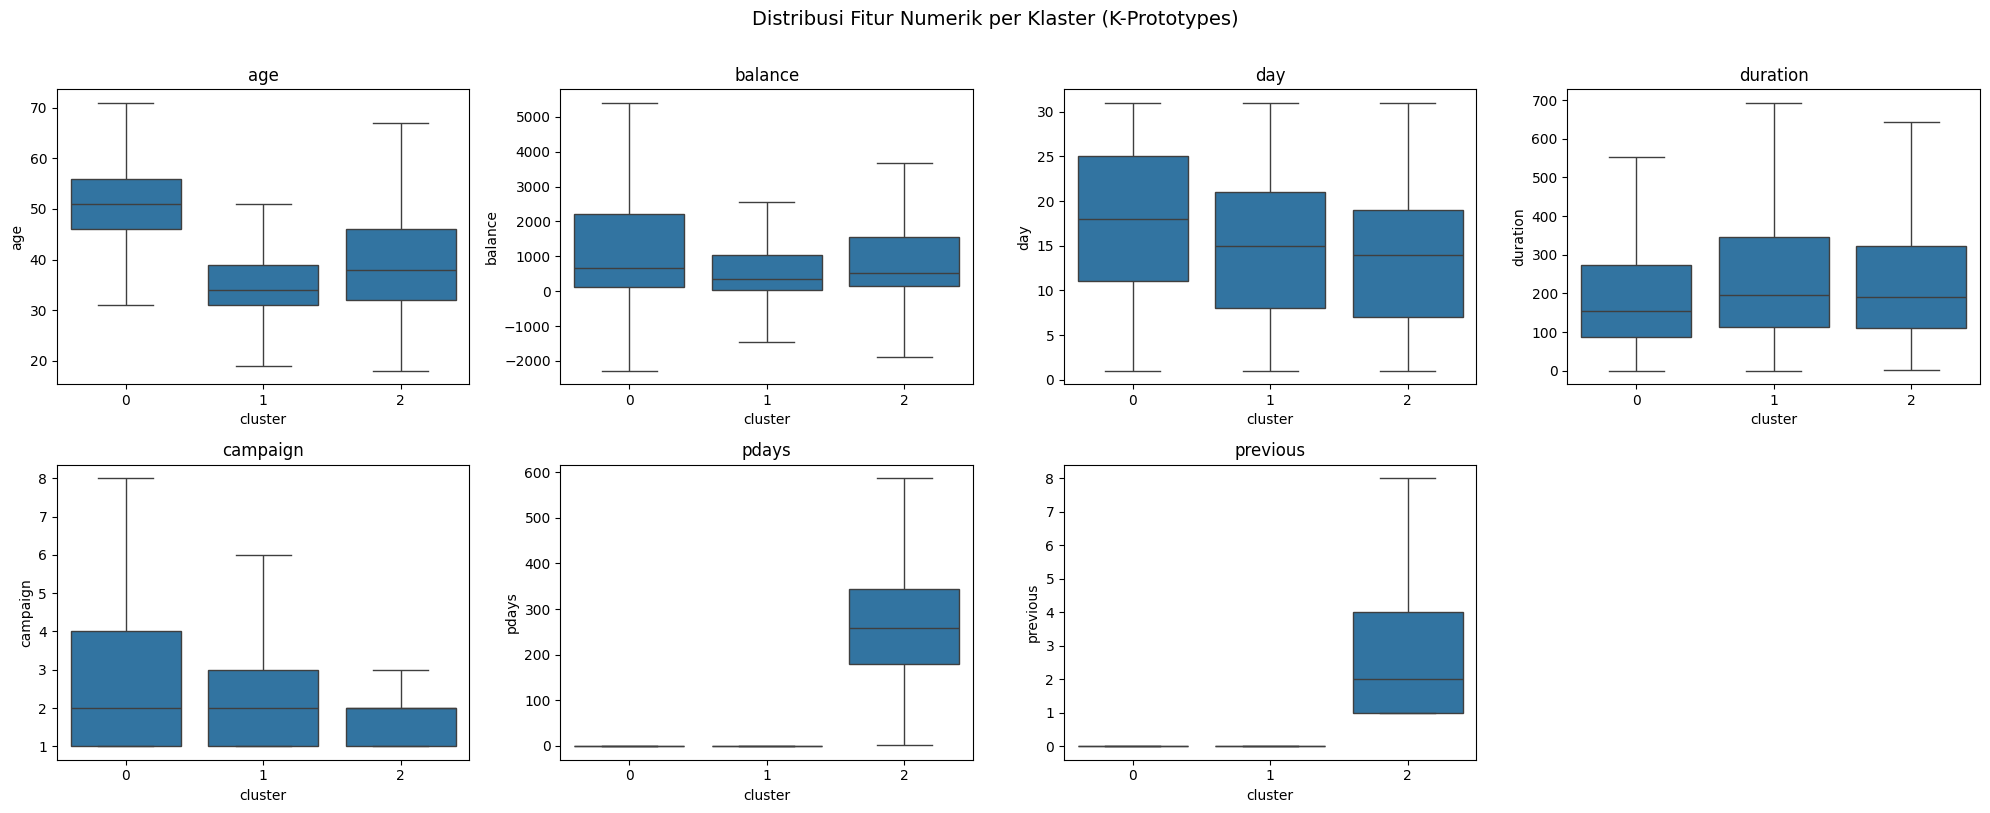

In [46]:
features_num = colnum

n_cols = 4
n_rows = int(np.ceil(len(features_num) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    sns.boxplot(x='cluster', y=feat, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(feat)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik per Klaster (K-Prototypes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Cluster 0 didominasi oleh nasabah dengan usia lebih tua dan saldo (balance) yang relatif tinggi serta variasi yang cukup besar. Namun, durasi interaksi (duration) mereka cenderung lebih singkat dan sebagian besar belum pernah dihubungi sebelumnya (pdays dan previous mendekati nol). Hal ini mengindikasikan bahwa meskipun secara finansial kuat, kelompok ini cenderung kurang responsif terhadap kampanye pemasaran atau membutuhkan pendekatan yang lebih tepat.

Sementara itu, Cluster 1 terdiri dari nasabah yang lebih muda dengan saldo paling rendah dibandingkan cluster lain. Meskipun demikian, mereka menunjukkan tingkat keterlibatan yang tinggi, terlihat dari durasi interaksi yang paling lama. Frekuensi kontak (campaign) juga cukup tinggi, meskipun mereka umumnya belum pernah dihubungi sebelumnya. Karakteristik ini menunjukkan bahwa kelompok ini memiliki potensi besar untuk dikonversi karena cenderung lebih terbuka dan responsif terhadap komunikasi, meskipun daya finansialnya relatif terbatas.

Di sisi lain, Cluster 2 berada di posisi menengah dari segi usia dan saldo. Kelompok ini memiliki durasi interaksi yang cukup baik, namun yang paling menonjol adalah tingginya nilai pdays dan previous, yang berarti mereka sudah sering dihubungi dalam kampanye sebelumnya. Meskipun frekuensi kontak saat ini relatif rendah, riwayat interaksi yang tinggi menunjukkan bahwa mereka merupakan nasabah yang sudah familiar dengan penawaran, tetapi mungkin belum berhasil dikonversi. Oleh karena itu, strategi yang berbeda atau lebih inovatif mungkin diperlukan untuk meningkatkan efektivitas pendekatan pada kelompok ini.

Secara keseluruhan, Cluster 1 tampak paling potensial untuk ditargetkan dalam kampanye karena tingkat keterlibatan yang tinggi, Cluster 0 memerlukan pendekatan yang lebih personal mengingat profilnya yang lebih mapan namun kurang responsif, sedangkan Cluster 2 membutuhkan evaluasi strategi karena intensitas kontak sebelumnya yang tinggi belum menghasilkan hasil yang optimal.

### Visualisasi distribusi fitur KATEGORIK per klaster menggunakan countplot

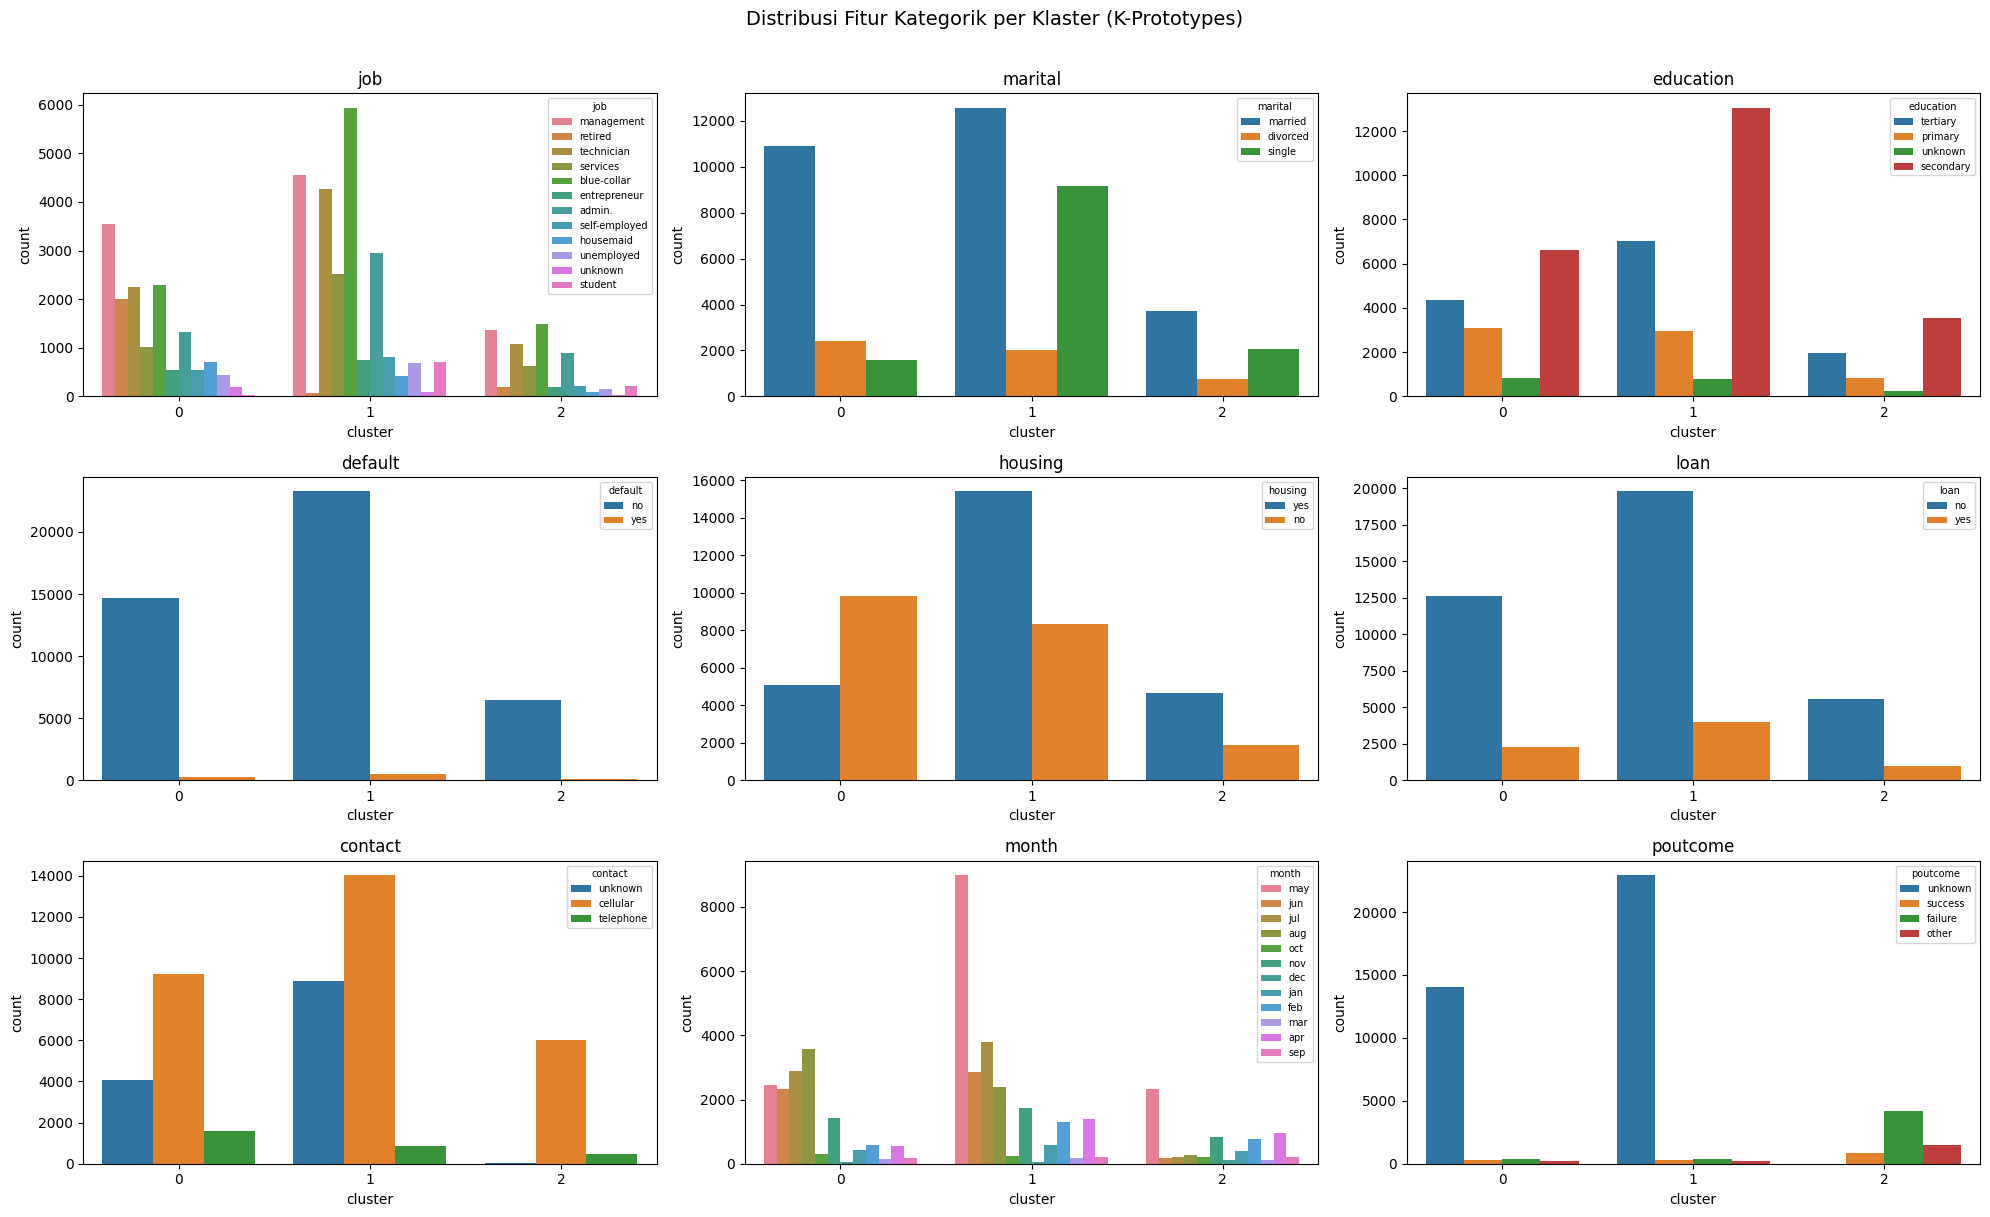

In [47]:
features_cat = colcat_names

n_cols = 3
n_rows = int(np.ceil(len(features_cat) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(features_cat):
    sns.countplot(x='cluster', hue=feat, data=df, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7, title=feat, title_fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Kategorik per Klaster (K-Prototypes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Secara umum, Cluster 0 didominasi oleh nasabah dengan pekerjaan seperti management, technician, dan blue-collar, dengan proporsi status menikah yang cukup tinggi. Dari sisi pendidikan, mayoritas berada pada tingkat secondary dan tertiary. Menariknya, sebagian besar tidak memiliki housing loan, dan juga tidak memiliki personal loan. Kontak lebih sering dilakukan melalui cellular, dan hasil kampanye sebelumnya (poutcome) didominasi oleh unknown, yang menunjukkan minimnya riwayat interaksi yang berhasil. Ini menggambarkan segmen yang relatif stabil namun belum banyak terlibat secara aktif dalam kampanye sebelumnya.

Sementara itu, Cluster 1 merupakan kelompok terbesar dengan distribusi pekerjaan yang lebih beragam, namun tetap didominasi oleh blue-collar, management, dan technician. Mereka mayoritas menikah, dengan tingkat pendidikan yang juga didominasi secondary. Berbeda dengan Cluster 0, sebagian besar dalam cluster ini memiliki housing loan, tetapi tetap didominasi tidak memiliki personal loan. Kontak paling banyak dilakukan melalui cellular, dan seperti cluster sebelumnya, poutcome masih didominasi oleh unknown. Hal ini menunjukkan bahwa meskipun kelompok ini cukup aktif dihubungi, keberhasilan kampanye sebelumnya belum signifikan.

Di sisi lain, Cluster 2 memiliki jumlah anggota paling sedikit dan karakteristik yang cukup berbeda. Pekerjaan dalam cluster ini lebih tersebar namun dalam jumlah kecil, dengan proporsi single dan married yang lebih seimbang dibanding cluster lain. Tingkat pendidikan tetap didominasi secondary, tetapi dalam skala lebih kecil. Mereka cenderung tidak memiliki housing loan maupun personal loan. Kontak juga didominasi oleh cellular, namun yang paling menonjol adalah hasil kampanye sebelumnya (poutcome) yang menunjukkan proporsi failure dan sebagian success yang lebih tinggi dibanding cluster lain. Ini menandakan bahwa kelompok ini memiliki riwayat interaksi yang lebih jelas (tidak “unknown”), tetapi responsnya cenderung kurang berhasil.

Secara keseluruhan, Cluster 1 merepresentasikan segmen terbesar dan paling aktif secara kontak, Cluster 0 merupakan segmen yang relatif stabil namun kurang memiliki riwayat interaksi yang jelas, sedangkan Cluster 2 adalah segmen kecil dengan riwayat kampanye yang lebih nyata namun cenderung kurang berhasil.

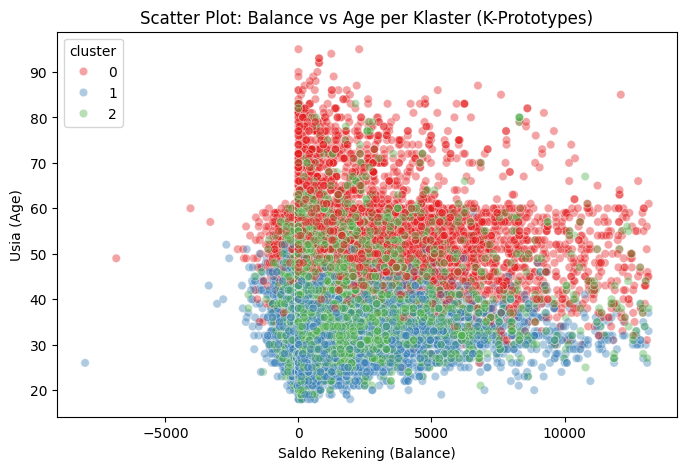

In [48]:
# Scatter plot: balance vs age, warna per klaster
# Menunjukkan sebaran nasabah di ruang 2D (saldo vs usia)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df[df['balance'] < df['balance'].quantile(0.99)],
    x='balance', y='age', hue='cluster', palette='Set1', alpha=0.4
)
plt.title('Scatter Plot: Balance vs Age per Klaster (K-Prototypes)')
plt.xlabel('Saldo Rekening (Balance)')
plt.ylabel('Usia (Age)')
plt.show()

Secara umum, terlihat bahwa tidak ada hubungan linear yang kuat antara usia dan saldo. Nasabah dengan saldo tinggi maupun rendah tersebar di berbagai rentang usia, sehingga usia bukan faktor utama yang menentukan besarnya saldo.

Jika dilihat per cluster, Cluster 0 (merah) didominasi oleh nasabah dengan usia lebih tua (sekitar 45–70 tahun) dan tersebar pada berbagai tingkat saldo, termasuk yang cukup tinggi. Ini menunjukkan bahwa kelompok ini cenderung lebih mapan secara usia dan memiliki kapasitas finansial yang lebih besar, meskipun variasinya tetap luas.

Cluster 1 (biru) terkonsentrasi pada usia yang lebih muda (sekitar 20–40 tahun) dengan saldo yang relatif lebih rendah hingga menengah. Sebarannya cukup rapat di area saldo rendah, menandakan kelompok ini merupakan nasabah muda dengan kondisi finansial yang masih berkembang.

Sementara itu, Cluster 2 (hijau) berada di antara keduanya, baik dari segi usia (sekitar 30–55 tahun) maupun saldo (rendah hingga menengah, dengan beberapa yang lebih tinggi). Cluster ini terlihat sebagai segmen transisi, tidak terlalu muda namun juga belum setua cluster 0, dengan kondisi finansial yang moderat.

Selain itu, terlihat bahwa sebagian besar data terkonsentrasi pada saldo positif rendah hingga menengah, dengan beberapa outlier pada saldo negatif maupun sangat tinggi.

### Ringkasan statistik per klaster

In [49]:
print('Profil Rata-Rata Tiap Klaster (Fitur Numerik)')
print(df.groupby('cluster')[colnum].mean().round(2).to_string())
print()
print('Mode Tiap Klaster (Fitur Kategorik)')
for feat in ['job', 'marital', 'education']:
    print(f'\n{feat}:')
    print(df.groupby('cluster')[feat].agg(lambda x: x.value_counts().index[0]))

Profil Rata-Rata Tiap Klaster (Fitur Numerik)
           age  balance    day  duration  campaign   pdays  previous
cluster                                                             
0        51.36  2080.11  17.63    223.30      3.86    5.76      0.13
1        34.77   908.59  15.20    279.99      2.26    2.03      0.06
2        39.60  1375.44  13.87    258.26      2.10  257.64      3.51

Mode Tiap Klaster (Fitur Kategorik)

job:
cluster
0     management
1    blue-collar
2    blue-collar
Name: job, dtype: str

marital:
cluster
0    married
1    married
2    married
Name: marital, dtype: str

education:
cluster
0    secondary
1    secondary
2    secondary
Name: education, dtype: str


### Interpretasi Hasil K-Prototypes

Cluster 0 didominasi oleh nasabah dengan usia paling tua (±51 tahun) dan saldo tertinggi (±2080), serta frekuensi kontak (campaign) paling tinggi. Durasi interaksi juga cukup besar, meskipun bukan yang tertinggi. Nilai pdays dan previous relatif rendah, yang menunjukkan bahwa mereka jarang dihubungi sebelumnya. Secara kategorik, cluster ini didominasi oleh pekerjaan management, dengan status menikah dan pendidikan secondary. Hal ini menunjukkan segmen nasabah yang lebih mapan secara finansial dan profesional, namun belum banyak terpapar kampanye sebelumnya.

Cluster 1 memiliki rata-rata usia paling muda (±35 tahun) dan saldo paling rendah (±908). Menariknya, durasi interaksi pada cluster ini adalah yang tertinggi (±280), yang mengindikasikan tingkat keterlibatan yang cukup baik. Frekuensi campaign berada di tingkat sedang, dan seperti Cluster 0, mereka hampir tidak memiliki riwayat kontak sebelumnya (pdays dan previous sangat rendah). Secara kategorik, didominasi oleh pekerjaan blue-collar, dengan status menikah dan pendidikan secondary. Cluster ini mencerminkan kelompok nasabah muda dengan daya finansial terbatas tetapi cukup responsif terhadap interaksi.

Cluster 2 berada di posisi menengah dari segi usia (±40 tahun) dan memiliki saldo yang cukup tinggi (±1375), namun yang paling menonjol adalah nilai pdays (±258) dan previous (±3.5) yang jauh lebih tinggi dibanding cluster lain. Ini menunjukkan bahwa mereka sudah sering dihubungi dalam kampanye sebelumnya. Durasi interaksi juga cukup tinggi, tetapi frekuensi campaign saat ini justru paling rendah. Secara kategorik, cluster ini juga didominasi oleh pekerjaan blue-collar, dengan status menikah dan pendidikan secondary. Hal ini menunjukkan bahwa cluster ini merupakan segmen “existing contact” yang sudah sering disentuh, namun kemungkinan belum berhasil dikonversi secara optimal.

Secara keseluruhan, perbedaan utama antar cluster terletak pada usia, saldo, dan terutama riwayat interaksi (pdays dan previous). Cluster 0 adalah segmen mapan yang belum banyak disentuh, Cluster 1 adalah segmen muda yang cukup responsif, dan Cluster 2 adalah segmen yang sudah sering dihubungi namun memerlukan strategi pendekatan yang lebih efektif.

## 6. Gower Distance + K-Means

In [51]:
import gower
from sklearn.cluster import KMeans
from sklearn.manifold import MDS

df_gower = df.drop(columns=['cluster']).sample(n=1000, random_state=42).reset_index(drop=True)

for col in df_gower.select_dtypes(include=['string']).columns:
    df_gower[col] = df_gower[col].astype(object)

gower_dist = gower.gower_matrix(df_gower)
gower_dist = np.asarray(gower_dist, dtype=np.float64)
print(f'{np.round(gower_dist[:5,:5], 3)}')


[[0.    0.284 0.337 0.431 0.406]
 [0.284 0.    0.371 0.426 0.418]
 [0.337 0.371 0.    0.328 0.351]
 [0.431 0.426 0.328 0.    0.271]
 [0.406 0.418 0.351 0.271 0.   ]]


DIsini kita ambil 1000 sampel untuk matriks Gower untuk menghemat memori

In [52]:
# Reduksi dimensi dengan MDS (Multidimensional Scaling)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=2, max_iter=100)
df_mds = mds.fit_transform(gower_dist)

C:\Users\MyBook Hype AMD\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\MyBook Hype AMD\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


### Elbow plot untuk menentukan K optimal pada Gower + K-Means

K=2, Inertia=33.2798
K=3, Inertia=20.8041
K=4, Inertia=15.3188
K=5, Inertia=11.8285
K=6, Inertia=9.7796
K=7, Inertia=8.4524
K=8, Inertia=7.3595
K=9, Inertia=6.4425


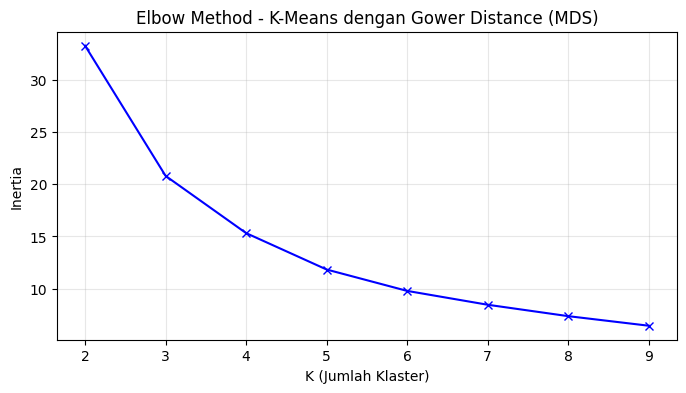

In [53]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_mds)
    inertia.append(km.inertia_)
    print(f'K={k}, Inertia={km.inertia_:.4f}')

plt.figure(figsize=(8,4))
plt.plot(list(k_range), inertia, 'bx-')
plt.xlabel('K (Jumlah Klaster)')
plt.ylabel('Inertia')
plt.title('Elbow Method - K-Means dengan Gower Distance (MDS)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

Grafik Elbow Method tersebut menunjukkan bahwa nilai inertia mengalami penurunan yang sangat tajam dari K=2 ke K=3 dan masih cukup signifikan hingga K=4, namun setelah itu penurunannya mulai melandai. Hal ini menandakan bahwa penambahan jumlah cluster setelah titik tersebut tidak lagi memberikan peningkatan yang berarti dalam meminimalkan variasi dalam cluster. Dengan demikian, titik “siku” (elbow) terlihat berada di sekitar K=3 hingga K=4, sehingga jumlah cluster optimal berada pada rentang tersebut. Jika mempertimbangkan keseimbangan antara kesederhanaan model dan kualitas segmentasi, maka K=3 dapat dianggap sebagai pilihan yang paling efisien, sementara K=4 dapat digunakan jika dibutuhkan segmentasi yang lebih rinci.

In [54]:
km_gower = KMeans(n_clusters=3, random_state=42, n_init=10)
gower_labels = km_gower.fit_predict(df_mds)

unique, counts = np.unique(gower_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Klaster {u}: {c} nasabah ({c/len(gower_labels)*100:.1f}%)')

Klaster 0: 354 nasabah (35.4%)
Klaster 1: 349 nasabah (34.9%)
Klaster 2: 297 nasabah (29.7%)


Didapatkan Distribusi Klaster degan Klaster ke 0 paling besar, yakni 35.4% kemudian disusul klaster 1 sebesar 34.9% dan klaster 2 sebesar 29.7%

### Visualisasi hasil clustering pada ruang MDS 2D

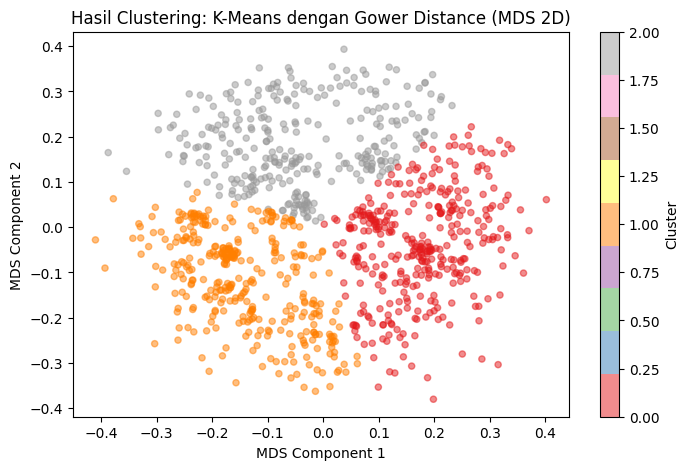

In [55]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(df_mds[:,0], df_mds[:,1], c=gower_labels, cmap='Set1', alpha=0.5, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title('Hasil Clustering: K-Means dengan Gower Distance (MDS 2D)')
plt.xlabel('MDS Component 1')
plt.ylabel('MDS Component 2')
plt.show()

Cluster berwarna merah (cluster 0) terkonsentrasi di sisi kanan grafik, menunjukkan kelompok dengan karakteristik yang berbeda dari cluster lain pada dimensi pertama (MDS Component 1). Cluster oranye (cluster 1) berada di sisi kiri bawah, dengan penyebaran yang cukup luas, menandakan variasi internal yang lebih tinggi dalam kelompok ini. Sementara itu, cluster abu-abu (cluster 2) cenderung berada di bagian atas tengah, relatif lebih terpisah secara vertikal dari dua cluster lainnya.

Pemisahan antar cluster terlihat cukup baik dengan overlap yang minimal, meskipun masih terdapat sedikit titik yang berdekatan di area perbatasan. Hal ini menunjukkan bahwa ketiga cluster memiliki karakteristik yang cukup berbeda, meskipun tidak sepenuhnya terpisah sempurna. Secara keseluruhan, hasil ini mendukung pemilihan jumlah cluster sebanyak tiga (K=3), karena struktur kelompok dalam data terlihat jelas dan cukup stabil dalam representasi dua dimensi ini.

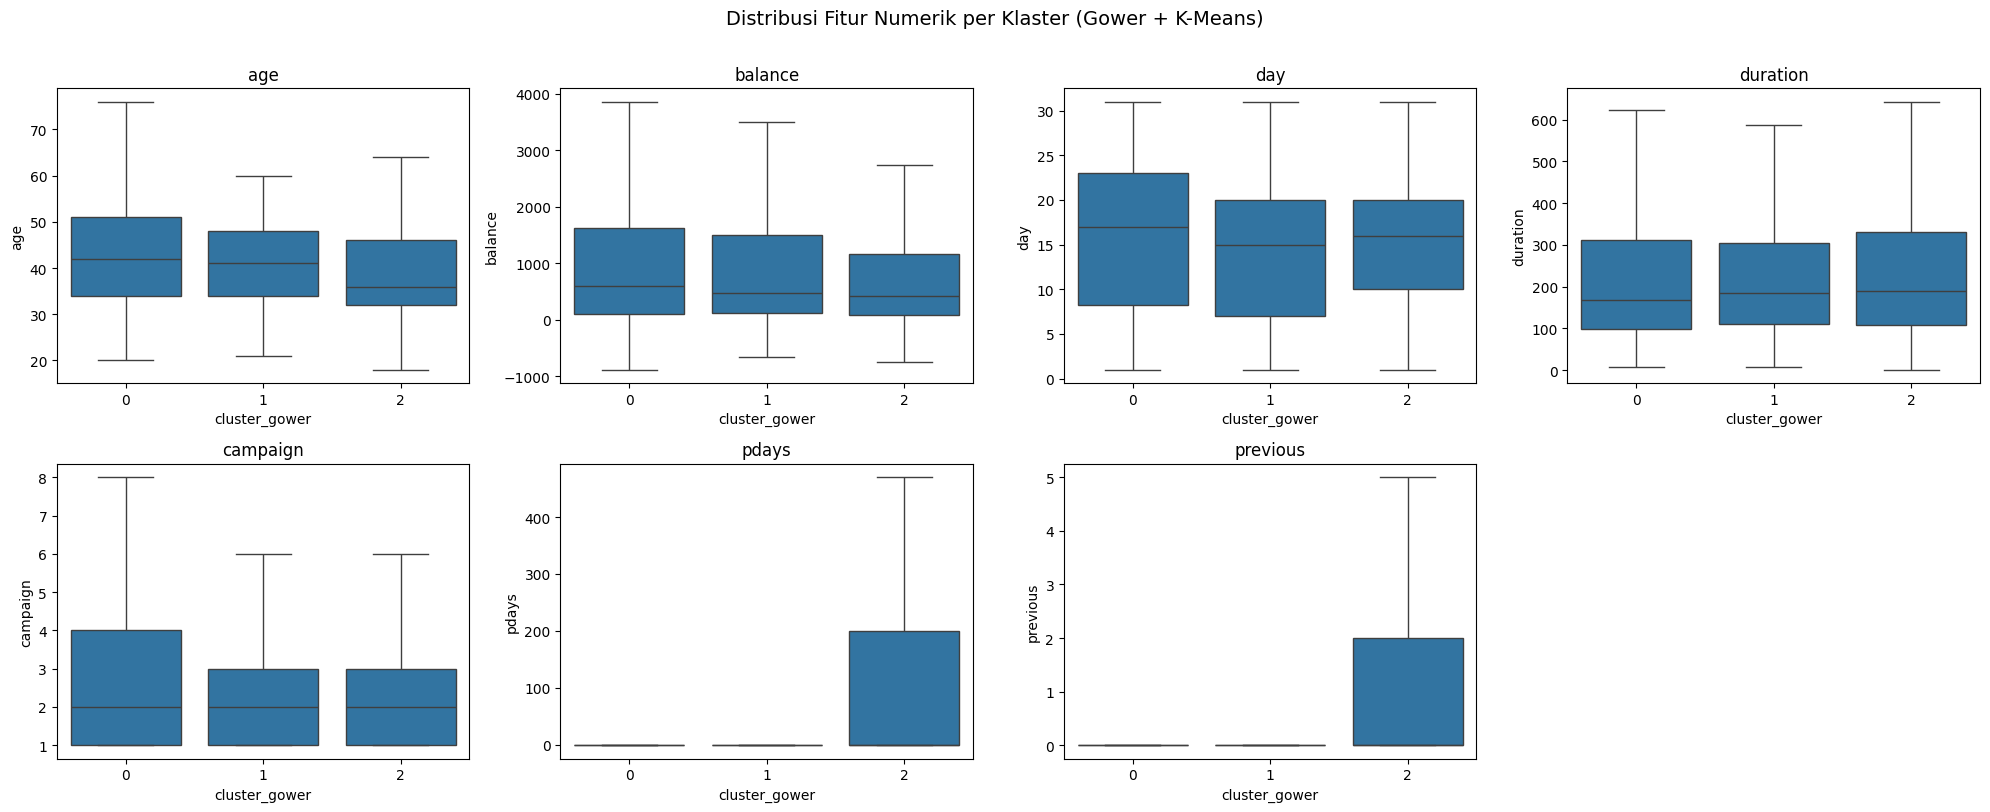

In [56]:
df_gower['cluster_gower'] = gower_labels

numeric_cols = df_gower.select_dtypes(exclude='object').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'cluster_gower']

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_cols):
    sns.boxplot(x='cluster_gower', y=feat, data=df_gower, ax=axes[i], showfliers=False)
    axes[i].set_title(feat)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik per Klaster (Gower + K-Means)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Cluster 0 terdiri dari nasabah dengan usia yang sedikit lebih tinggi dibanding cluster lain, serta memiliki variasi saldo yang cukup besar dan cenderung lebih tinggi. Durasi kontak pada cluster ini relatif sedang, sementara jumlah campaign (frekuensi kontak) juga sedikit lebih tinggi dibanding cluster lain. Namun, seperti terlihat pada variabel pdays dan previous, sebagian besar nasabah di cluster ini belum memiliki riwayat kontak sebelumnya. Hal ini menunjukkan bahwa mereka adalah segmen yang cukup potensial namun belum banyak dieksplorasi dalam kampanye sebelumnya.

Cluster 1 menunjukkan karakteristik yang cukup mirip dengan Cluster 0, tetapi dengan usia yang sedikit lebih muda dan saldo yang sedikit lebih rendah. Durasi interaksi berada pada tingkat sedang, dan frekuensi campaign juga relatif moderat. Sama seperti Cluster 0, kelompok ini hampir tidak memiliki riwayat kontak sebelumnya (pdays dan previous mendekati nol). Cluster ini dapat dianggap sebagai segmen “umum” atau rata-rata yang tidak terlalu menonjol pada satu karakteristik tertentu.

Sementara itu, Cluster 2 memiliki ciri yang paling berbeda, terutama pada variabel pdays dan previous yang jauh lebih tinggi dibandingkan cluster lain. Ini menunjukkan bahwa nasabah dalam cluster ini sudah sering dihubungi dalam kampanye sebelumnya. Dari segi usia, mereka cenderung sedikit lebih muda dibanding Cluster 0, dengan saldo yang berada pada tingkat menengah. Durasi kontak pada cluster ini juga relatif lebih tinggi, yang mengindikasikan tingkat keterlibatan yang cukup baik. Namun, tingginya frekuensi kontak sebelumnya bisa juga menandakan bahwa mereka belum berhasil dikonversi meskipun sudah sering dihubungi.

Secara keseluruhan, perbedaan utama antar cluster terletak pada riwayat interaksi (pdays dan previous), di mana Cluster 2 merupakan kelompok dengan intensitas kontak tertinggi, sedangkan Cluster 0 dan 1 relatif belum banyak tersentuh. Sementara itu, fitur seperti usia, saldo, dan durasi menunjukkan perbedaan yang ada namun tidak terlalu ekstrem, sehingga berperan sebagai pembeda tambahan dalam segmentasi.

## 7. FAMD + K-Means

### Tanpa FAMD vs Dengan FAMD

**Tanpa FAMD:** Kita langsung menerapkan K-Means pada data raw, tapi karena ada kolom kategorik, kita harus melakukan one-hot encoding terlebih dahulu. Ini bisa menghasilkan data berdimensi sangat tinggi (curse of dimensionality).

**Dengan FAMD (Factor Analysis of Mixed Data):** FAMD adalah metode reduksi dimensi yang dirancang untuk mixed data. Cara kerjanya:
1. Menskalakan variabel numerik (seperti PCA)
2. Menerapkan Multiple Correspondence Analysis (MCA) untuk variabel kategorik
3. Menggabungkan keduanya dalam satu ruang "laten" berdimengi rendah

Setelah transformasi FAMD, kita bisa menerapkan K-Means standar pada koordinat laten tersebut.


### TANPA FAMD: One-Hot Encoding + K-Means

In [57]:
import prince

df_ohe = df.drop(columns=['cluster']).copy()
df_ohe = pd.get_dummies(df_ohe, columns=colcat_names)

# Scaling seluruh kolom setelah OHE
scaler2 = StandardScaler()
df_ohe_scaled = scaler2.fit_transform(df_ohe)

print('Shape data TANPA FAMD (setelah OHE):', df_ohe_scaled.shape)

Shape data TANPA FAMD (setelah OHE): (45211, 51)


### Elbow plot TANPA FAMD (K-Means langsung pada OHE data)

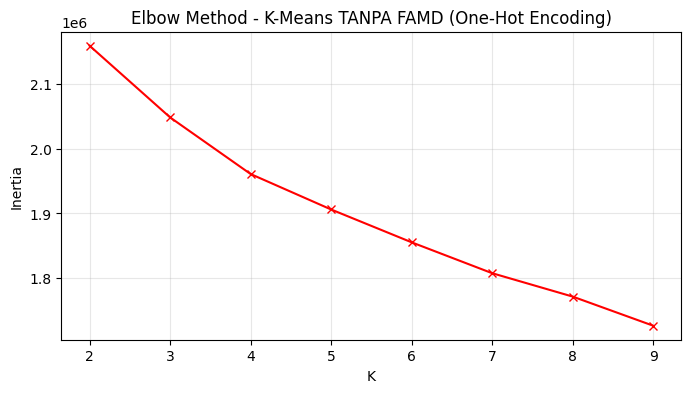

In [58]:
inertia_ohe = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_ohe_scaled)
    inertia_ohe.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(list(k_range), inertia_ohe, 'rx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method - K-Means TANPA FAMD (One-Hot Encoding)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

Grafik Elbow Method tersebut menunjukkan hubungan antara jumlah cluster (K) dan nilai inertia pada K-Means yang menggunakan One-Hot Encoding (tanpa FAMD). Terlihat bahwa nilai inertia menurun secara konsisten seiring bertambahnya jumlah cluster, namun penurunannya cenderung tidak menunjukkan “siku” yang jelas seperti pada metode sebelumnya.

Penurunan terbesar terjadi dari K=2 ke K=3 dan masih cukup terlihat hingga K=4, tetapi setelah itu penurunannya menjadi lebih gradual dan relatif linear. Hal ini menunjukkan bahwa penambahan cluster terus memperbaiki model, tetapi tidak ada titik optimal yang benar-benar menonjol sebagai batas terbaik jumlah cluster.

Kondisi ini mengindikasikan bahwa representasi data menggunakan One-Hot Encoding kemungkinan membuat struktur cluster menjadi kurang kompak atau lebih menyebar, sehingga sulit menemukan pemisahan alami antar kelompok. Dibandingkan dengan pendekatan Gower Distance sebelumnya, hasil ini terlihat kurang tegas dalam menentukan jumlah cluster optimal.

Secara praktis, K=3 atau K=4 masih bisa dipilih sebagai kompromi antara kompleksitas dan performa, namun keputusan tersebut tidak sekuat pada metode sebelumnya. Hal ini memperkuat bahwa penggunaan Gower Distance atau metode yang lebih sesuai untuk data campuran memberikan hasil clustering yang lebih jelas dan terstruktur dibandingkan One-Hot Encoding.

### K-Means TANPA FAMD dengan K=3

In [59]:
km_ohe = KMeans(n_clusters=3, random_state=42, n_init=10)
ohe_labels = km_ohe.fit_predict(df_ohe_scaled)

print('Distribusi klaster K-Means TANPA FAMD:')
unique, counts = np.unique(ohe_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Klaster {u}: {c} nasabah ({c/len(ohe_labels)*100:.1f}%)')

Distribusi klaster K-Means TANPA FAMD:
Klaster 0: 8254 nasabah (18.3%)
Klaster 1: 21906 nasabah (48.5%)
Klaster 2: 15051 nasabah (33.3%)


Didapatkan Distribusi Klaster K-Means tanpa FAMD degan Klaster ke 1 paling besar, yakni 48.5% kemudian disusul klaster 2 sebesar 33.3% dan klaster 0 sebesar 18.3%

### DENGAN FAMD: Reduksi dimensi + K-Means

In [60]:
df_famd_input = df.drop(columns=['cluster']).copy()

for col in colcat_names:
    df_famd_input[col] = df_famd_input[col].astype(str)
for col in colnum:
    df_famd_input[col] = pd.to_numeric(df_famd_input[col])

print('Shape input FAMD:', df_famd_input.shape)

Shape input FAMD: (45211, 16)


In [62]:
for col in df_famd_input.select_dtypes(include=['int', 'int32', 'int64']).columns:
    df_famd_input[col] = df_famd_input[col].astype(float)

famd = prince.FAMD(
    n_components=5,
    n_iter=3,
    copy=True,
    random_state=42
)
famd = famd.fit(df_famd_input)
df_famd_transformed = famd.transform(df_famd_input)

print('Shape SETELAH FAMD:', df_famd_transformed.shape)

Shape SETELAH FAMD: (45211, 5)


### Elbow plot dengan FAMD

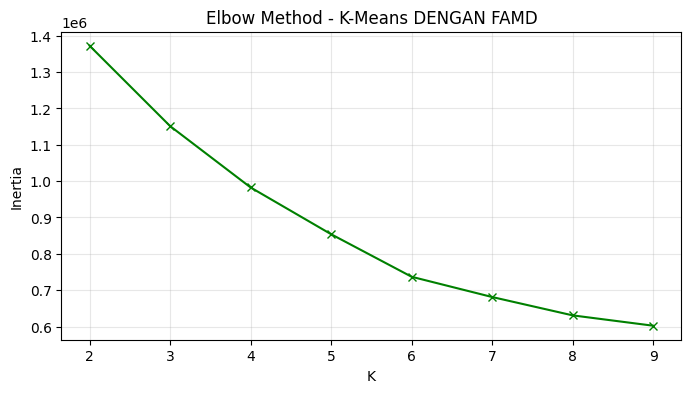

In [63]:
inertia_famd = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_famd_transformed)
    inertia_famd.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(list(k_range), inertia_famd, 'gx-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method - K-Means DENGAN FAMD')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

Grafik Elbow Method tersebut menunjukkan hasil K-Means setelah menggunakan FAMD (Factor Analysis for Mixed Data), yang bertujuan mereduksi dimensi sekaligus menangani data campuran numerik dan kategorik dengan lebih baik. Terlihat bahwa nilai inertia menurun cukup tajam dari K=2 hingga sekitar K=5, kemudian setelah itu penurunannya mulai melandai.

Penurunan yang paling signifikan terjadi pada rentang K=2 sampai K=4, dan masih cukup terlihat hingga K=5 atau K=6, namun setelah itu kurva menjadi lebih datar. Hal ini menunjukkan bahwa penambahan cluster di atas titik tersebut tidak lagi memberikan peningkatan yang berarti dalam kualitas pengelompokan.

Dengan demikian, titik “elbow” paling masuk akal berada di sekitar K=4 hingga K=5. Artinya, jumlah cluster optimal kemungkinan berada pada rentang tersebut. Jika mengutamakan model yang lebih sederhana dan mudah diinterpretasikan, K=4 dapat menjadi pilihan yang baik, sedangkan K=5 dapat dipilih jika ingin segmentasi yang sedikit lebih detail.

Secara keseluruhan, dibandingkan metode tanpa FAMD, grafik ini menunjukkan pola elbow yang lebih jelas, yang menandakan bahwa penggunaan FAMD membantu menghasilkan struktur cluster yang lebih terdefinisi dan lebih mudah diinterpretasikan.

In [64]:
km_famd = KMeans(n_clusters=3, random_state=42, n_init=10)
famd_labels = km_famd.fit_predict(df_famd_transformed)

print('Distribusi klaster FAMD + K-Means:')
unique, counts = np.unique(famd_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Klaster {u}: {c} nasabah ({c/len(famd_labels)*100:.1f}%)')

Distribusi klaster FAMD + K-Means:
Klaster 0: 18724 nasabah (41.4%)
Klaster 1: 11028 nasabah (24.4%)
Klaster 2: 15459 nasabah (34.2%)


Didapatkan Distribusi Klaster K-Means FAMD + K-Means dengan Klaster ke 0 paling besar, yakni 41.4% kemudian disusul klaster 2 sebesar 34.2% dan klaster 1 sebesar 24.4%

### Perbandingan visualisasi: Tanpa FAMD vs Dengan FAMD

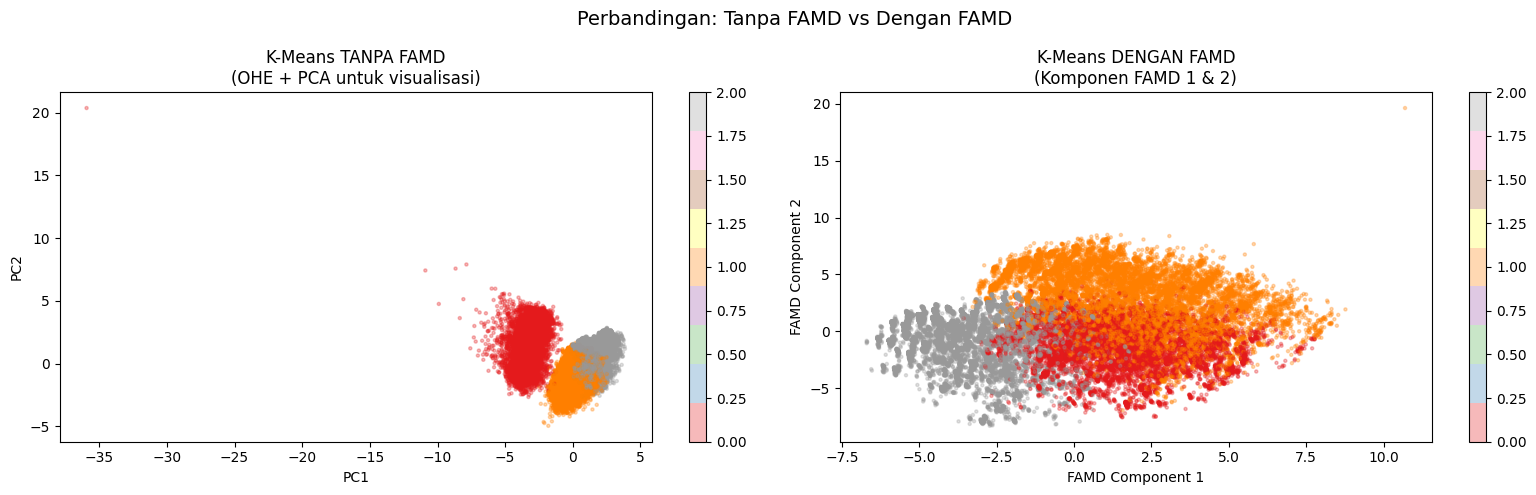

In [65]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
df_ohe_2d = pca_vis.fit_transform(df_ohe_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scatter1 = axes[0].scatter(df_ohe_2d[:,0], df_ohe_2d[:,1],
                           c=ohe_labels, cmap='Set1', alpha=0.3, s=5)
axes[0].set_title('K-Means TANPA FAMD\n(OHE + PCA untuk visualisasi)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(
    df_famd_transformed.iloc[:,0],
    df_famd_transformed.iloc[:,1],
    c=famd_labels, cmap='Set1', alpha=0.3, s=5
)
axes[1].set_title('K-Means DENGAN FAMD\n(Komponen FAMD 1 & 2)')
axes[1].set_xlabel('FAMD Component 1')
axes[1].set_ylabel('FAMD Component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.suptitle('Perbandingan: Tanpa FAMD vs Dengan FAMD', fontsize=14)
plt.tight_layout()
plt.show()

Pada visualisasi tanpa FAMD (OHE + PCA) di sebelah kiri, terlihat bahwa cluster memang terbentuk, tetapi pemisahannya cenderung kurang optimal. Titik-titik data tampak cukup padat dan beberapa cluster masih relatif berdekatan, bahkan ada indikasi overlap ringan. Hal ini menunjukkan bahwa transformasi menggunakan One-Hot Encoding diikuti PCA belum sepenuhnya mampu menangkap struktur alami data campuran secara efektif.

Sebaliknya, pada visualisasi dengan FAMD di sebelah kanan, distribusi data terlihat lebih menyebar dan struktur cluster menjadi lebih jelas. Meskipun masih ada sedikit overlap, masing-masing cluster memiliki area yang lebih terdefinisi dan pemisahan antar kelompok tampak lebih natural. FAMD membantu menggabungkan informasi dari fitur numerik dan kategorik secara lebih seimbang, sehingga representasi data menjadi lebih informatif sebelum dilakukan clustering.

Secara keseluruhan, pendekatan dengan FAMD menghasilkan kualitas clustering yang lebih baik dibandingkan tanpa FAMD. Hal ini terlihat dari struktur cluster yang lebih jelas, distribusi yang lebih representatif, serta kemampuan yang lebih baik dalam memisahkan kelompok berdasarkan karakteristik data campuran.

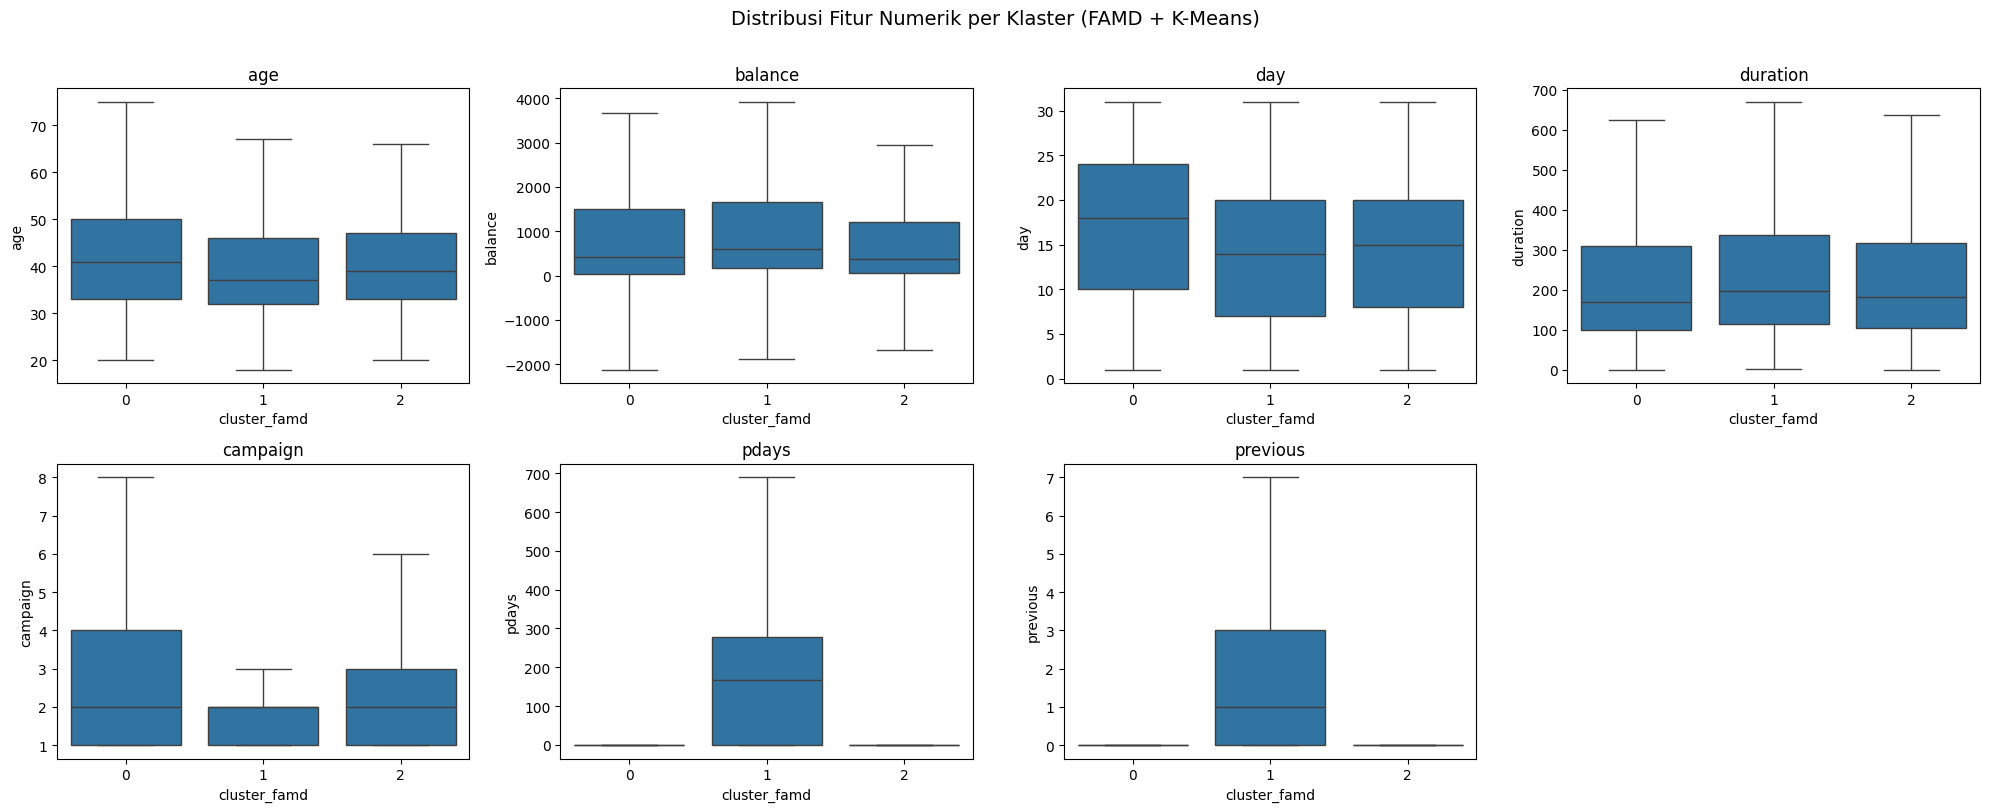

In [66]:
df['cluster_famd'] = famd_labels
df['cluster_ohe'] = ohe_labels

n_cols = 4
n_rows = int(np.ceil(len(colnum) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(colnum):
    sns.boxplot(x='cluster_famd', y=feat, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(feat)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik per Klaster (FAMD + K-Means)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Cluster 0 cenderung terdiri dari nasabah dengan usia menengah (sekitar 35–45 tahun) dan saldo yang cukup baik, meskipun masih bervariasi. Durasi interaksi berada pada tingkat sedang, dan jumlah campaign relatif lebih tinggi dibanding cluster lain. Nilai pdays dan previous hampir nol, yang menunjukkan bahwa kelompok ini sebagian besar belum pernah dihubungi sebelumnya. Ini mengindikasikan segmen yang cukup potensial karena belum banyak disentuh oleh kampanye sebelumnya.

Cluster 1 menunjukkan karakteristik yang paling menonjol pada variabel pdays dan previous, dengan nilai yang jauh lebih tinggi dibanding cluster lain. Artinya, nasabah dalam cluster ini sudah sering dihubungi sebelumnya. Selain itu, durasi interaksi juga cenderung lebih tinggi, yang menandakan adanya keterlibatan yang cukup baik. Dari sisi usia dan saldo, cluster ini berada di tingkat menengah. Namun, tingginya riwayat kontak bisa mengindikasikan bahwa mereka merupakan target berulang yang belum berhasil dikonversi secara optimal.

Sementara itu, Cluster 2 memiliki profil yang relatif mirip dengan Cluster 0 dari segi usia dan saldo, namun dengan frekuensi campaign yang lebih rendah. Nilai pdays dan previous juga sangat rendah, menunjukkan minimnya riwayat interaksi sebelumnya. Durasi interaksi berada pada tingkat sedang. Cluster ini dapat dianggap sebagai segmen yang “netral” atau belum banyak dieksplorasi, dengan potensi yang masih terbuka.

Secara keseluruhan, pembeda utama antar cluster kembali terlihat pada riwayat interaksi (pdays dan previous) serta intensitas campaign, sementara variabel seperti usia, saldo, dan durasi berperan sebagai pembeda tambahan. Cluster 1 menonjol sebagai kelompok dengan intensitas kontak tinggi, sedangkan Cluster 0 dan 2 lebih merupakan segmen yang belum banyak disentuh dan berpotensi untuk dikembangkan melalui strategi pemasaran yang lebih tepat.

## 8. K-Prototypes dengan FAMD

In [73]:
df_famd_kp = df.drop(columns=['cluster', 'cluster_famd', 'cluster_ohe'], errors='ignore').copy()

for col in colcat_names:
    df_famd_kp[col] = df_famd_kp[col].astype(str)

for col in colnum:
    df_famd_kp[col] = pd.to_numeric(df_famd_kp[col]).astype(float)

famd_kp = prince.FAMD(
    n_components=5,
    n_iter=3,
    copy=True,
    random_state=42
)
famd_kp = famd_kp.fit(df_famd_kp)

print(f'Shape data input: {df_famd_kp.shape}')

Shape data input: (45211, 16)


### Mengekstrak Kontribusi Fitur Numerik

In [74]:
df_famd_coords = famd_kp.transform(df_famd_kp)

print('Korelasi fitur numerik dengan komponen FAMD:')
corr_df = pd.DataFrame(index=colnum, columns=[f'Comp{i+1}' for i in range(5)])

for col in colnum:
    for i in range(5):
        corr_df.loc[col, f'Comp{i+1}'] = abs(df_famd_kp[col].corr(df_famd_coords.iloc[:, i]))

corr_df = corr_df.astype(float)
corr_df['total_contribution'] = (corr_df**2).sum(axis=1)
corr_df_sorted = corr_df.sort_values('total_contribution', ascending=False)

print(corr_df_sorted.round(4))

Korelasi fitur numerik dengan komponen FAMD:
           Comp1   Comp2   Comp3   Comp4   Comp5  total_contribution
pdays     0.1850  0.6122  0.2781  0.2583  0.0851              0.5604
age       0.0544  0.3275  0.3912  0.0454  0.2241              0.3156
previous  0.1716  0.3612  0.1872  0.1817  0.0164              0.2282
campaign  0.0035  0.1601  0.0436  0.1079  0.0244              0.0398
day       0.0528  0.0264  0.0516  0.1539  0.0864              0.0373
balance   0.1176  0.0471  0.0195  0.1240  0.0488              0.0342
duration  0.0076  0.0253  0.0104  0.0189  0.0188              0.0015


Terlihat bahwa pdays (0.5604) memiliki kontribusi paling besar, diikuti oleh age (0.3156) dan previous (0.2282). Ini menunjukkan bahwa struktur utama data, dan pada akhirnya pembentukan cluster sangat dipengaruhi oleh riwayat interaksi nasabah (kapan terakhir dihubungi dan seberapa sering) serta usia. Dengan kata lain, variabel-variabel ini adalah faktor utama yang membedakan antar segmen.

Sementara itu, fitur seperti campaign (0.0398), day (0.0373), dan balance (0.0342) memiliki kontribusi yang jauh lebih kecil, sehingga pengaruhnya dalam membentuk cluster relatif terbatas. Bahkan, duration (0.0015) hampir tidak berkontribusi, yang berarti variabel ini tidak terlalu membantu dalam membedakan kelompok nasabah dalam konteks FAMD.

Secara keseluruhan, dapat disimpulkan bahwa dimensi utama hasil FAMD lebih banyak merepresentasikan pola riwayat kontak nasabah dibandingkan faktor finansial atau operasional lainnya. Hal ini juga konsisten dengan hasil clustering sebelumnya, di mana variabel seperti pdays dan previous menjadi pembeda paling kuat antar cluster.

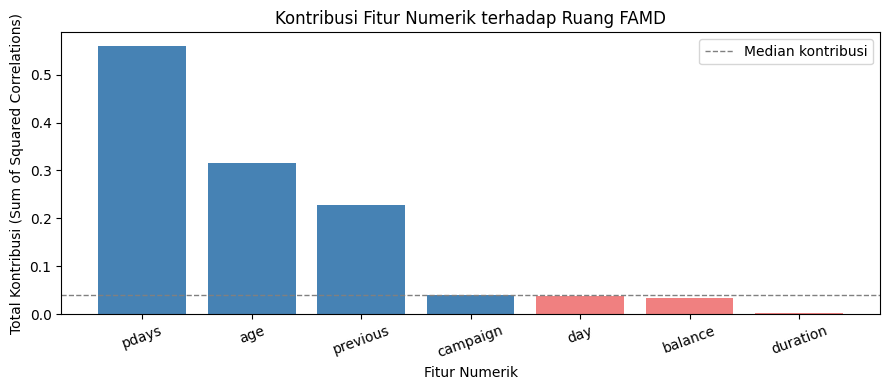

Threshold (median): 0.0398


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))
colors = ['steelblue' if v >= corr_df_sorted['total_contribution'].median() 
          else 'lightcoral' for v in corr_df_sorted['total_contribution']]
bars = plt.bar(corr_df_sorted.index, corr_df_sorted['total_contribution'], color=colors)
plt.axhline(y=corr_df_sorted['total_contribution'].median(), 
            color='gray', linestyle='--', linewidth=1, label='Median kontribusi')
plt.title('Kontribusi Fitur Numerik terhadap Ruang FAMD')
plt.xlabel('Fitur Numerik')
plt.ylabel('Total Kontribusi (Sum of Squared Correlations)')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

# Tentukan threshold: fitur di atas median dipertahankan
threshold = corr_df_sorted['total_contribution'].median()
selected_num = corr_df_sorted[corr_df_sorted['total_contribution'] >= threshold].index.tolist()
dropped_num  = corr_df_sorted[corr_df_sorted['total_contribution'] <  threshold].index.tolist()

print(f'Threshold (median): {threshold:.4f}')

Terlihat bahwa pdays memiliki kontribusi paling dominan, jauh di atas fitur lainnya, diikuti oleh age dan previous. Ketiga fitur ini berada jauh di atas garis median, yang berarti mereka adalah faktor utama dalam membentuk struktur dimensi FAMD dan sangat berpengaruh dalam proses clustering. Hal ini menegaskan bahwa riwayat interaksi nasabah (pdays dan previous) serta usia menjadi pembeda paling kuat antar cluster.

Sementara itu, campaign berada tepat di sekitar ambang median, sehingga kontribusinya bisa dianggap cukup tetapi tidak dominan. Di sisi lain, day, balance, dan terutama duration berada di bawah garis median, yang menunjukkan bahwa fitur-fitur tersebut memiliki pengaruh yang relatif kecil dalam membentuk struktur cluster. Khususnya duration, kontribusinya hampir nol, sehingga perannya dalam membedakan kelompok nasabah sangat minimal dalam konteks ini.

Secara keseluruhan, grafik ini memperjelas bahwa tidak semua fitur numerik berperan sama pentingnya, dan bahwa segmentasi nasabah lebih banyak ditentukan oleh pola kontak sebelumnya dan karakteristik usia, dibandingkan faktor finansial seperti saldo atau durasi interaksi.

### Scaling Fitur Numerik Berbobot Kontribusi FAMD

In [77]:
from sklearn.preprocessing import StandardScaler

df_kp_famd = df_famd_kp[selected_num + colcat_names].copy()

print(f'Numerik: {selected_num}')
print(f'Kategorik: {colcat_names}')

# Scaling fitur numerik terpilih dengan StandardScaler
sc_kpf = StandardScaler()
df_kp_famd_scaled = df_kp_famd.copy()
df_kp_famd_scaled[selected_num] = sc_kpf.fit_transform(df_kp_famd[selected_num])

weights = corr_df_sorted.loc[selected_num, 'total_contribution'].values
weights_norm = 0.5 + (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
for feat, w in zip(selected_num, weights_norm):
    print(f'{feat}: {w:.4f}')

for feat, w in zip(selected_num, weights_norm):
    df_kp_famd_scaled[feat] = df_kp_famd_scaled[feat] * w

colcat_kpf = [list(df_kp_famd_scaled.columns).index(col) for col in colcat_names]

Numerik: ['pdays', 'age', 'previous', 'campaign']
Kategorik: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
pdays: 1.5000
age: 1.0297
previous: 0.8619
campaign: 0.5000


Hasil tersebut menunjukkan bobot kontribusi fitur setelah dinormalisasi, di mana pdays (1.5) menjadi faktor paling dominan dalam membentuk cluster, diikuti oleh age (≈1.03) dan previous (≈0.86) yang juga masih berpengaruh cukup kuat. Sementara itu, campaign (0.5) memiliki kontribusi paling rendah, sehingga perannya dalam membedakan cluster relatif kecil. Secara singkat, segmentasi terutama ditentukan oleh riwayat kontak (pdays & previous) dan usia, bukan frekuensi campaign.

### Elbow Method untuk K-Prototype + FAMD

In [78]:
from kmodes.kprototypes import KPrototypes

df_kpf_sample = df_kp_famd_scaled.sample(n=3000, random_state=42).reset_index(drop=True)

costs_kpf = []
n_clusters_kpf = []

for i in range(2, 10):
    try:
        kpf = KPrototypes(n_clusters=i, random_state=10, init='Huang', n_init=1, verbose=0)
        kpf.fit_predict(df_kpf_sample, categorical=colcat_kpf)
        costs_kpf.append(kpf.cost_)
        n_clusters_kpf.append(i)
        print(f'K={i}, Cost={kpf.cost_:.4f}')
    except Exception as e:
        print(f'K={i} gagal: {e}')

K=2, Cost=11595.0529
K=3, Cost=10708.6042
K=4, Cost=8846.6365
K=5, Cost=8266.8695
K=6, Cost=7838.9132
K=7, Cost=6899.1573
K=8, Cost=6994.9061
K=9, Cost=6217.9391


Nilai cost turun cukup tajam dari K=2 ke K=4, lalu penurunannya mulai melambat setelah itu. Ini berarti titik optimal ada di sekitar K=3 atau K=4.

Sederhananya, jumlah cluster terbaik ada di 3–4, karena setelah itu peningkatannya tidak terlalu signifikan.

### Visualisasi Elbow Plot K-Prototypes + FAMD

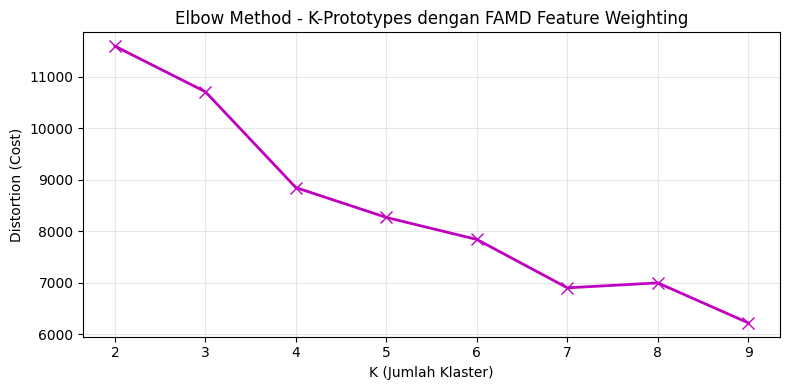

In [79]:
plt.figure(figsize=(8, 4))
plt.plot(n_clusters_kpf, costs_kpf, 'mx-', linewidth=2, markersize=8)
plt.ylabel('Distortion (Cost)')
plt.xlabel('K (Jumlah Klaster)')
plt.title('Elbow Method - K-Prototypes dengan FAMD Feature Weighting')
plt.xticks(n_clusters_kpf)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafik menunjukkan penurunan cost cukup tajam sampai K=3, lalu setelah itu penurunannya lebih kecil.

Artinya, titik terbaik ada di sekitar K=3.

### Fit K-Prototypes + FAMD pada Data Penuh

In [80]:
kpf_final = KPrototypes(n_clusters=3, random_state=10, init='Huang', n_init=1, verbose=1)
kpf_labels = kpf_final.fit_predict(df_kp_famd_scaled, categorical=colcat_kpf)

print('\nDistribusi Klaster K-Prototypes + FAMD')
unique_kpf, counts_kpf = np.unique(kpf_labels, return_counts=True)
for u, c in zip(unique_kpf, counts_kpf):
    print(f'Klaster {u}: {c} nasabah ({c/len(kpf_labels)*100:.1f}%)')

df['cluster_kpf'] = kpf_labels

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 2042, ncost: 164459.89787347373
Run: 1, iteration: 2/100, moves: 758, ncost: 163898.15397025185
Run: 1, iteration: 3/100, moves: 227, ncost: 163853.9089704247
Run: 1, iteration: 4/100, moves: 48, ncost: 163850.30466924183
Run: 1, iteration: 5/100, moves: 10, ncost: 163850.0805920898
Run: 1, iteration: 6/100, moves: 3, ncost: 163850.04516655975
Run: 1, iteration: 7/100, moves: 0, ncost: 163850.04516655975

Distribusi Klaster K-Prototypes + FAMD
Klaster 0: 3599 nasabah (8.0%)
Klaster 1: 4384 nasabah (9.7%)
Klaster 2: 37228 nasabah (82.3%)


Hasil clustering menunjukkan bahwa data terbagi menjadi tiga kelompok, namun distribusinya tidak seimbang. Sebagian besar data (sekitar 82%) masuk ke Cluster 2, sehingga cluster ini menjadi kelompok dominan. Sementara itu, Cluster 0 dan Cluster 1 hanya berisi sebagian kecil data, masing-masing sekitar 8% dan 10%. Secara sederhana, ini berarti mayoritas nasabah memiliki karakteristik yang mirip dan terkumpul dalam satu cluster besar, sedangkan dua cluster lainnya merepresentasikan segmen yang lebih kecil dan spesifik.

### Visualisasi Distribusi Fitur Numerik per Klaster

C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\512151832.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kpf', y=feat, data=df, ax=axes[i], showfliers=False,
C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\512151832.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kpf', y=feat, data=df, ax=axes[i], showfliers=False,
C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_18420\512151832.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_kpf', y=feat, data=df, ax=axes[i], showfli

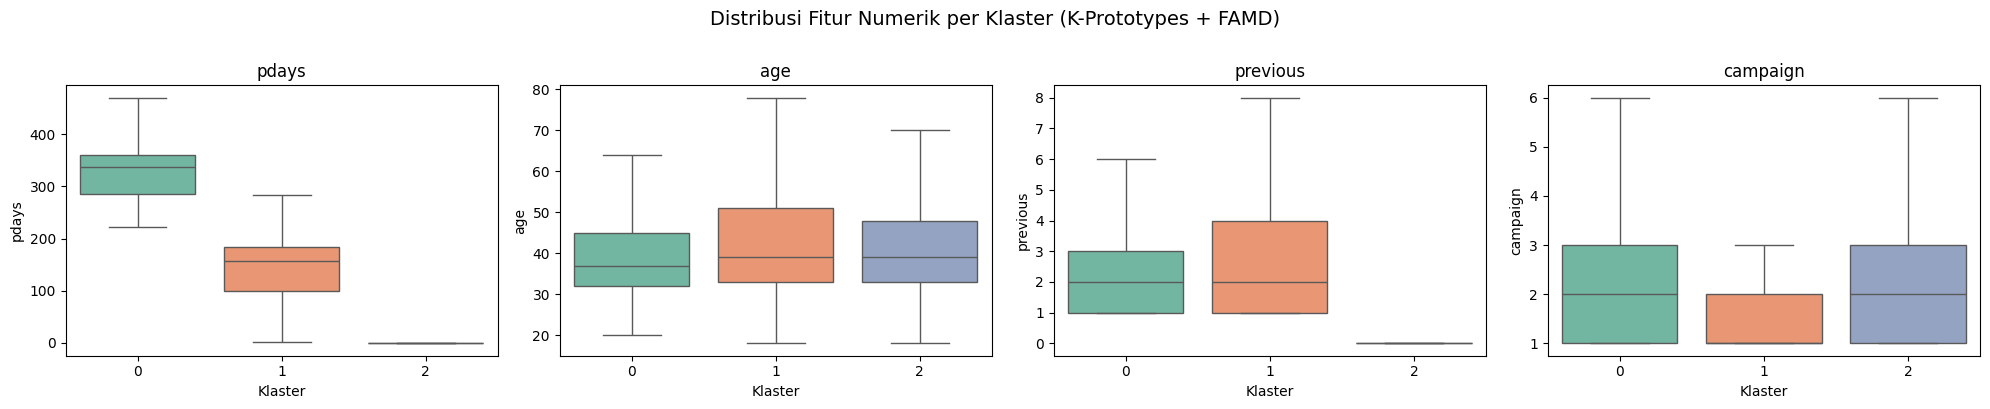

In [81]:
n_cols = 4
n_rows = int(np.ceil(len(selected_num) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(selected_num):
    sns.boxplot(x='cluster_kpf', y=feat, data=df, ax=axes[i], showfliers=False,
                palette='Set2')
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Klaster')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Numerik per Klaster (K-Prototypes + FAMD)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Cluster 0 memiliki nilai pdays paling tinggi, yang berarti nasabah dalam kelompok ini sudah lama tidak dihubungi kembali, serta memiliki nilai previous yang cukup tinggi, menandakan adanya riwayat kontak sebelumnya. Usia pada cluster ini cenderung berada di rentang menengah, dan frekuensi campaign juga relatif sedang. Ini menunjukkan segmen nasabah yang pernah dihubungi, tetapi sudah cukup lama tidak tersentuh kembali.

Cluster 1 memiliki nilai pdays yang lebih rendah dibanding Cluster 0, yang berarti kontak terakhir dengan nasabah lebih baru. Nilai previous pada cluster ini juga cukup tinggi, bahkan sedikit lebih tinggi dari Cluster 0, menunjukkan bahwa mereka cukup sering dihubungi sebelumnya. Usia cenderung lebih bervariasi, dan frekuensi campaign relatif rendah hingga sedang. Cluster ini dapat diartikan sebagai nasabah yang cukup aktif dalam interaksi, tetapi belum tentu berhasil dikonversi.

Sementara itu, Cluster 2 memiliki nilai pdays dan previous yang hampir nol, yang menunjukkan bahwa nasabah dalam kelompok ini hampir tidak memiliki riwayat kontak sebelumnya. Usia berada pada tingkat menengah, dan frekuensi campaign juga tidak terlalu tinggi. Ini menggambarkan segmen nasabah yang masih “baru” atau belum banyak disentuh dalam aktivitas pemasaran.

Secara keseluruhan, perbedaan utama antar cluster kembali terletak pada riwayat interaksi nasabah (pdays dan previous), di mana Cluster 0 dan 1 adalah kelompok yang sudah pernah dihubungi (dengan intensitas dan waktu yang berbeda), sedangkan Cluster 2 adalah kelompok yang belum banyak tersentuh dan berpotensi untuk menjadi target baru.

### Visualisasi Distribusi Fitur Kategorik per Klaster

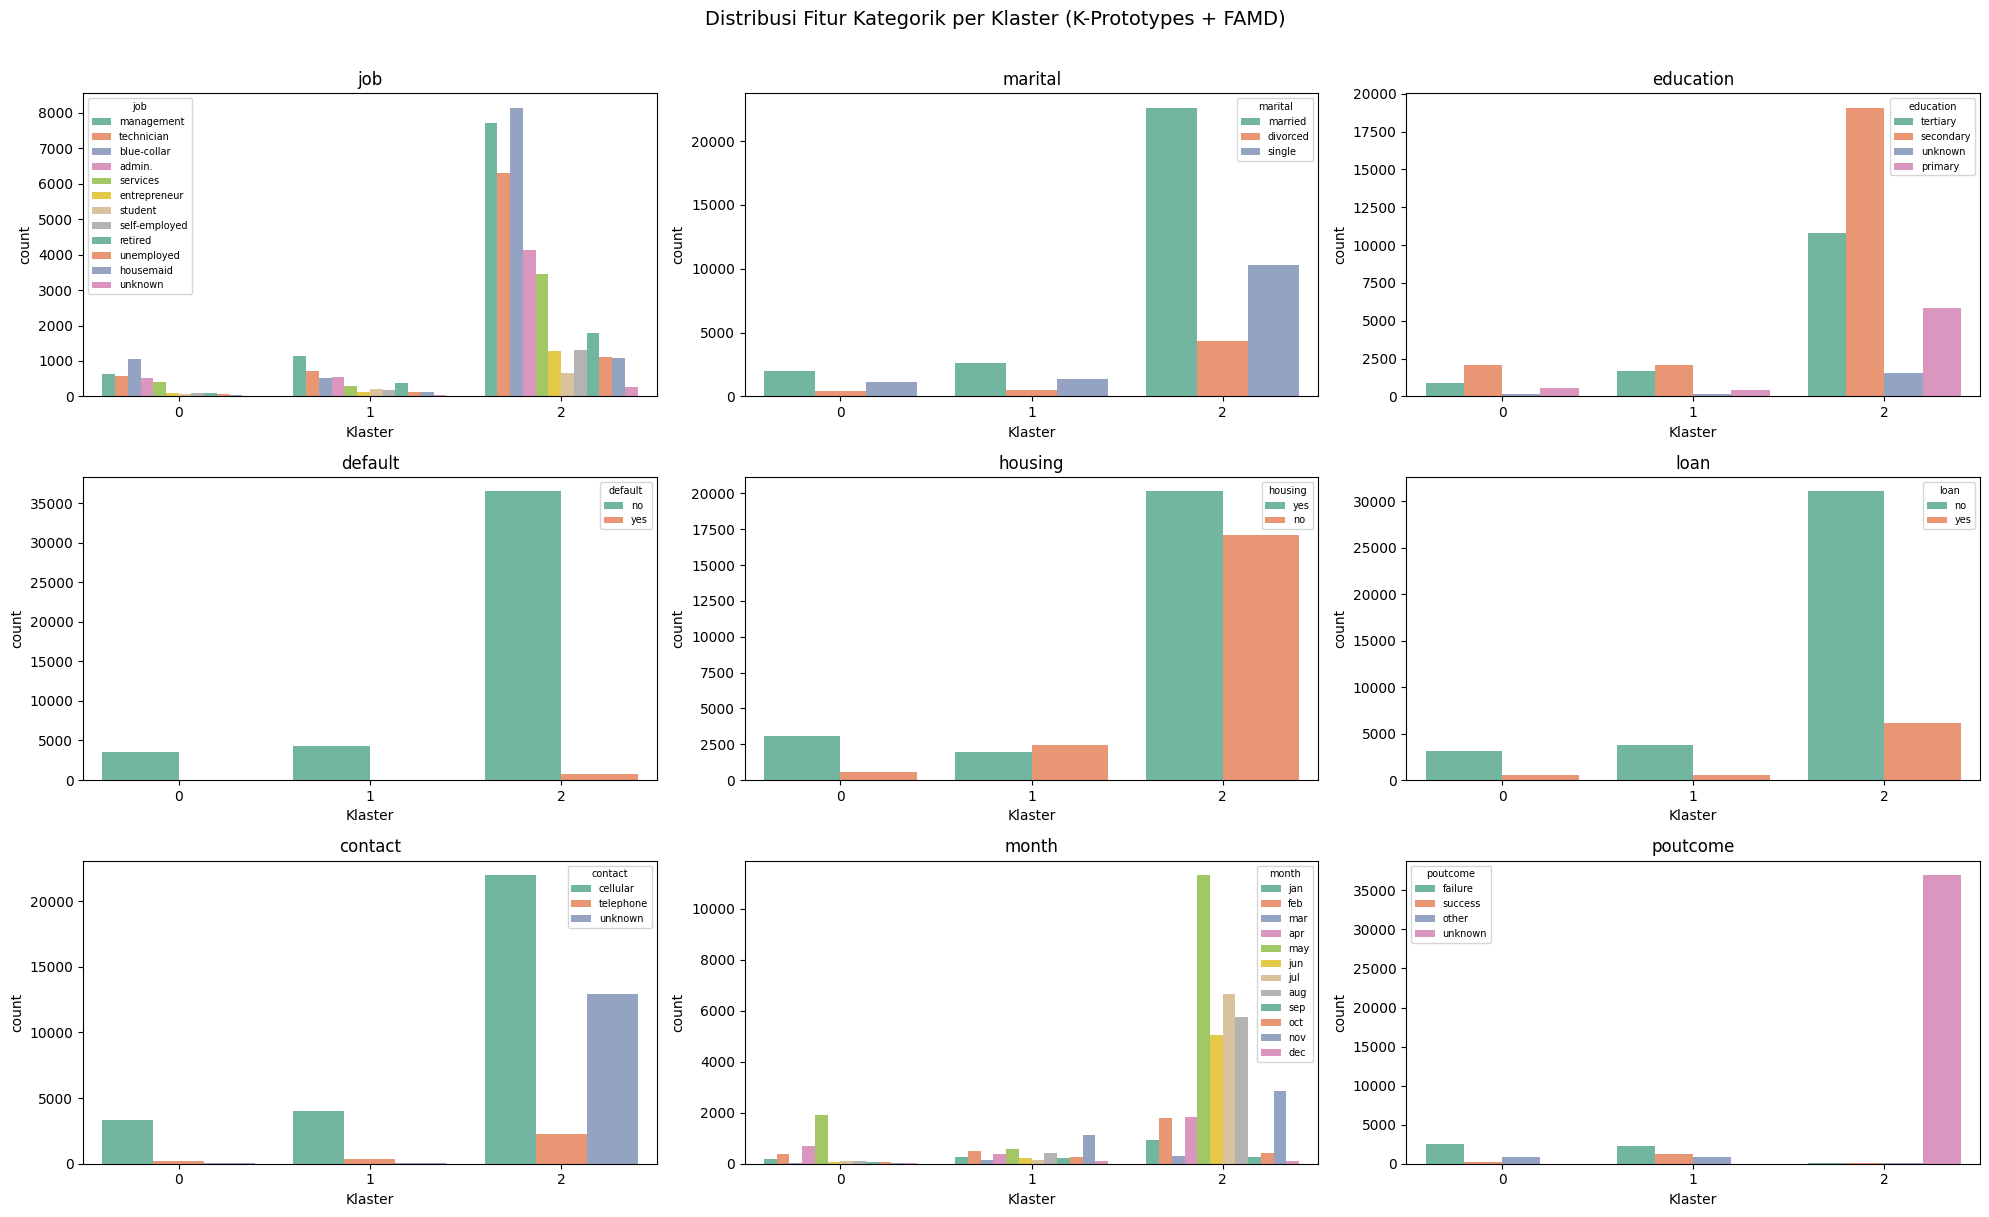

In [82]:
n_cols = 3
n_rows = int(np.ceil(len(colcat_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(colcat_names):
    sns.countplot(x='cluster_kpf', hue=feat, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(feat, fontsize=12)
    axes[i].legend(fontsize=7, title=feat, title_fontsize=7)
    axes[i].set_xlabel('Klaster')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Fitur Kategorik per Klaster (K-Prototypes + FAMD)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Cluster 2 merupakan kelompok terbesar dan paling dominan. Cluster ini didominasi oleh pekerjaan seperti blue-collar, technician, dan management, dengan mayoritas berstatus menikah dan berpendidikan secondary. Sebagian besar tidak memiliki default dan personal loan, namun cukup banyak yang memiliki housing loan. Kontak paling sering dilakukan melalui cellular, dan poutcome didominasi oleh unknown, yang menunjukkan bahwa sebagian besar interaksi sebelumnya belum memiliki hasil yang jelas. Cluster ini merepresentasikan segmen mayoritas nasabah dengan karakteristik umum.

Cluster 0 memiliki jumlah yang jauh lebih kecil dan cenderung lebih beragam dari sisi pekerjaan, meskipun masih didominasi beberapa kategori umum. Status pernikahan tetap didominasi menikah, dengan pendidikan secondary. Mereka umumnya tidak memiliki loan maupun default, dan kontak juga lebih sering melalui cellular. Pola poutcome juga masih didominasi oleh unknown, sehingga menunjukkan minimnya hasil kampanye yang terdokumentasi. Cluster ini dapat dilihat sebagai segmen kecil dengan karakteristik relatif standar.

Sementara itu, Cluster 1 juga merupakan kelompok kecil dengan karakteristik yang mirip dengan Cluster 0, namun dengan sedikit variasi pada distribusi pekerjaan dan kepemilikan housing loan yang lebih beragam. Status menikah dan pendidikan secondary tetap mendominasi. Pola kontak dan hasil kampanye juga serupa, dengan dominasi cellular dan poutcome unknown.

Secara keseluruhan, ketiga cluster memiliki kemiripan pada fitur kategorik seperti status pernikahan (mayoritas menikah), pendidikan (secondary), serta dominasi kontak melalui cellular. Perbedaan antar cluster tidak terlalu kuat pada fitur kategorik, sehingga dapat disimpulkan bahwa segmentasi lebih banyak dipengaruhi oleh fitur numerik (terutama riwayat kontak) dibandingkan oleh karakteristik kategorik.

### Scatter Plot Balance vs Age

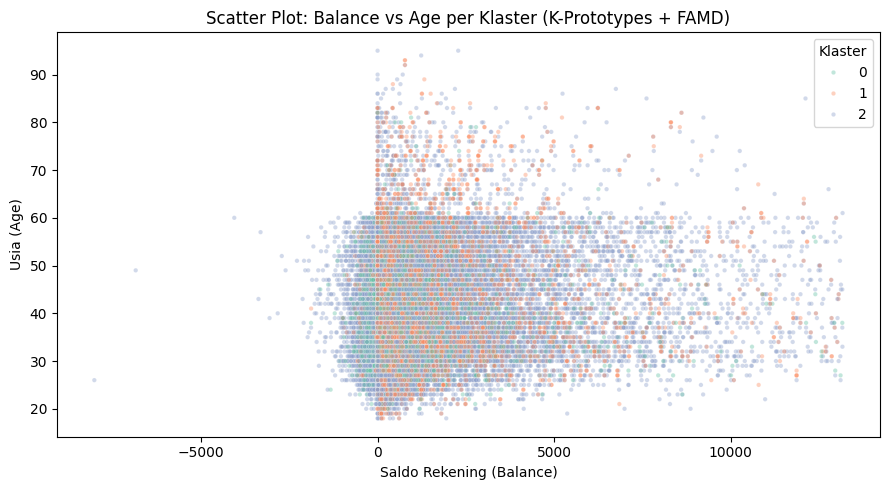

In [83]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df[df['balance'] < df['balance'].quantile(0.99)],
    x='balance', y='age',
    hue='cluster_kpf', palette='Set2', alpha=0.4, s=10
)
plt.title('Scatter Plot: Balance vs Age per Klaster (K-Prototypes + FAMD)')
plt.xlabel('Saldo Rekening (Balance)')
plt.ylabel('Usia (Age)')
plt.legend(title='Klaster')
plt.tight_layout()
plt.show()

Terlihat bahwa ketiga cluster cukup banyak overlap dan tidak terpisah secara jelas dalam ruang 2D ini. Artinya, berdasarkan hanya dua variabel ini (usia dan saldo), pemisahan cluster tidak terlalu kuat.

Sebagian besar data terkonsentrasi pada saldo rendah hingga menengah dan usia sekitar 25–60 tahun. Cluster tersebar di area yang hampir sama, meskipun ada sedikit kecenderungan bahwa cluster tertentu lebih dominan di rentang usia atau saldo tertentu, namun tidak membentuk batas yang tegas.

Hal ini menunjukkan bahwa usia dan saldo bukan faktor utama yang membedakan cluster, melainkan kombinasi fitur lain (terutama hasil transformasi FAMD seperti riwayat kontak). Selain itu, karena ini hanya visualisasi 2 dimensi, wajar jika pemisahan tidak terlihat jelas, karena struktur cluster sebenarnya terbentuk di ruang dimensi yang lebih tinggi.

Tabel rata-rata dan mode di atas adalah ringkasan paling langsung untuk memahami tiap klaster. Dari sini kita bisa mulai memberi label intuitif pada tiap segmen, misalnya:

- Klaster dengan usia tinggi, saldo tinggi, pekerjaan `management` atau `retired` bisa dilabeli sebagai **"Nasabah Mapan"**
- Klaster dengan usia muda, saldo rendah, pekerjaan `blue-collar` atau `services` bisa dilabeli **"Nasabah Aktif Produktif"**
- Klaster dengan saldo menengah dan housing loan aktif bisa dilabeli **"Nasabah Keluarga Menengah"**

Label spesifik harus disesuaikan dengan angka aktual yang muncul saat notebook dijalankan.

### Heatmap Profil Klaster

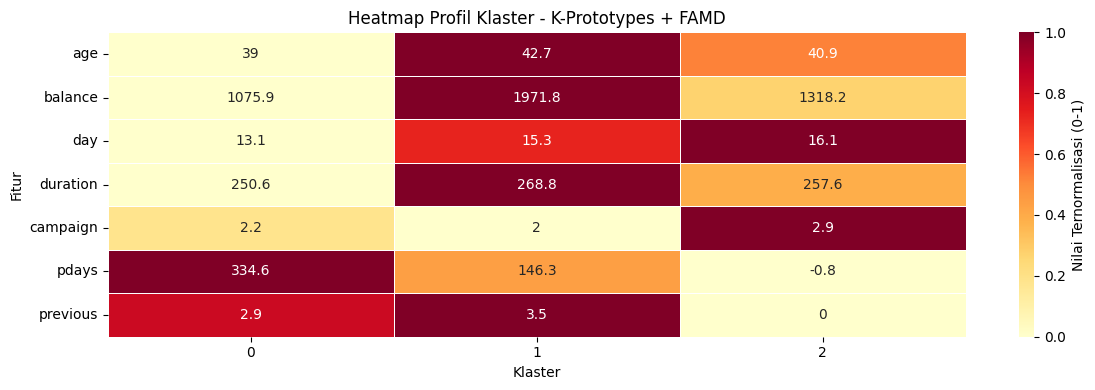

In [84]:
cluster_profile = df.groupby('cluster_kpf')[colnum].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min() + 1e-9)

plt.figure(figsize=(12, 4))
sns.heatmap(
    cluster_profile_norm.T,
    annot=cluster_profile.T.round(1),
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Nilai Ternormalisasi (0-1)'}
)
plt.title('Heatmap Profil Klaster - K-Prototypes + FAMD')
plt.xlabel('Klaster')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

Cluster 1 terlihat paling menonjol secara finansial dan interaksi, dengan usia tertinggi (~42.7), saldo tertinggi (~1971.8), serta durasi interaksi paling lama dan previous tertinggi. Ini menunjukkan segmen nasabah yang cukup mapan dan cukup aktif dalam interaksi.

Cluster 0 memiliki ciri pdays dan previous yang tinggi, artinya nasabah di kelompok ini sudah pernah dihubungi sebelumnya dan cukup lama sejak kontak terakhir. Namun saldo dan usia berada di tingkat menengah. Ini bisa diartikan sebagai nasabah lama yang sudah jarang disentuh kembali.

Cluster 2 berbeda paling jelas, dengan pdays dan previous hampir nol, yang menunjukkan hampir tidak ada riwayat kontak sebelumnya. Selain itu, meskipun usia dan saldo berada di tingkat menengah, cluster ini memiliki campaign tertinggi, yang berarti mereka lebih sering dihubungi dalam periode saat ini.

Secara sederhana, perbedaan utama antar cluster terletak pada riwayat dan intensitas interaksi (pdays, previous, campaign), bukan hanya faktor usia atau saldo.

### Perbandingan dengan K-Prototypes Standar

In [85]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Perbandingan distribusi klaster
print('Perbandingan Distribusi Klaster')
print('\nK-Prototypes Standar:')
print(df['cluster'].value_counts().sort_index())
print('\nK-Prototypes + FAMD:')
print(df['cluster_kpf'].value_counts().sort_index())

ari = adjusted_rand_score(df['cluster'], df['cluster_kpf'])
print(f'\nAdjusted Rand Index (K-Proto Standar vs K-Proto+FAMD): {ari:.4f}')

# Silhouette Score
from sklearn.preprocessing import LabelEncoder
df_num_only = df[colnum].copy()
sc_sil = StandardScaler()
df_num_scaled_sil = sc_sil.fit_transform(df_num_only)

sil_kp  = silhouette_score(df_num_scaled_sil, df['cluster'],     sample_size=5000, random_state=42)
sil_kpf = silhouette_score(df_num_scaled_sil, df['cluster_kpf'], sample_size=5000, random_state=42)

print(f'\nSilhouette Score:')
print(f'K-Prototypes Standar : {sil_kp:.4f}')
print(f'K-Prototypes + FAMD  : {sil_kpf:.4f}')

Perbandingan Distribusi Klaster

K-Prototypes Standar:
cluster
0    14905
1    23773
2     6533
Name: count, dtype: int64

K-Prototypes + FAMD:
cluster_kpf
0     3599
1     4384
2    37228
Name: count, dtype: int64

Adjusted Rand Index (K-Proto Standar vs K-Proto+FAMD): 0.3294

Silhouette Score:
K-Prototypes Standar : 0.1861
K-Prototypes + FAMD  : 0.2531


Hasil tersebut menunjukkan bahwa terdapat perbedaan yang cukup jelas antara K-Prototypes standar dan K-Prototypes + FAMD. Pada metode standar, distribusi cluster relatif lebih seimbang, sedangkan pada metode dengan FAMD, sebagian besar data terkonsentrasi pada satu cluster besar, sehingga distribusinya tidak merata.

Nilai Adjusted Rand Index sebesar 0.3294 menunjukkan bahwa kesamaan antara kedua hasil clustering tergolong rendah hingga sedang, sehingga struktur cluster yang dihasilkan cukup berbeda. Namun, dari sisi kualitas, metode dengan FAMD memiliki Silhouette Score yang lebih tinggi (0.2531) dibandingkan metode standar (0.1861). Ini berarti cluster yang dihasilkan dengan FAMD lebih kompak dan lebih terpisah dengan baik.

Secara sederhana, K-Prototypes standar menghasilkan pembagian cluster yang lebih seimbang, tetapi kurang optimal dalam pemisahan, sedangkan K-Prototypes + FAMD menghasilkan cluster yang lebih berkualitas meskipun distribusinya cenderung tidak seimbang.

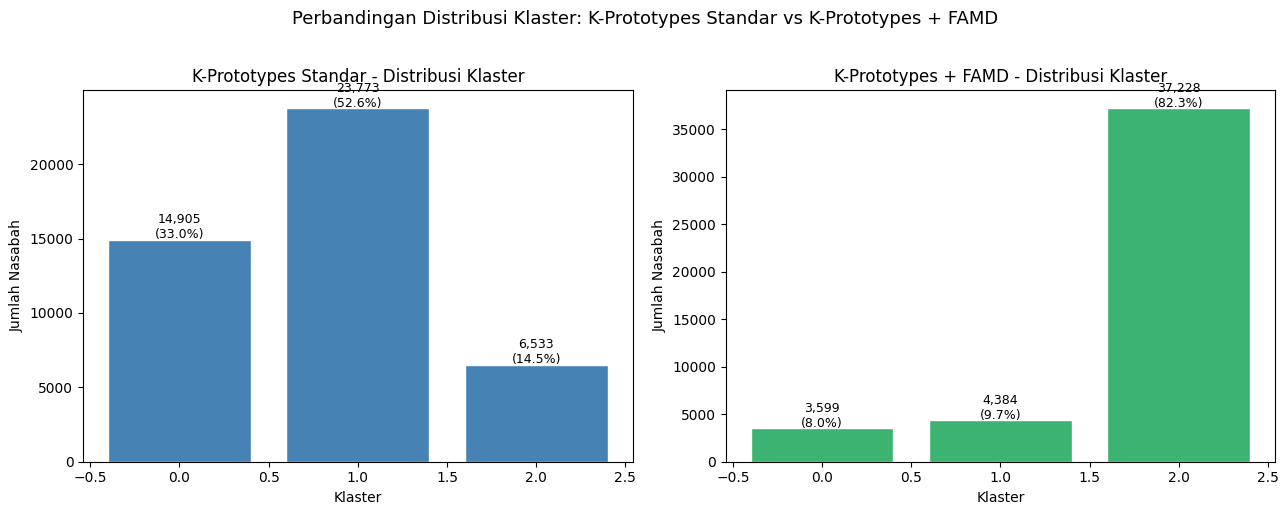

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Prototypes Standar
kp_counts = df['cluster'].value_counts().sort_index()
axes[0].bar(kp_counts.index, kp_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('K-Prototypes Standar - Distribusi Klaster', fontsize=12)
axes[0].set_xlabel('Klaster')
axes[0].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(kp_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# K-Prototypes + FAMD
kpf_counts = df['cluster_kpf'].value_counts().sort_index()
axes[1].bar(kpf_counts.index, kpf_counts.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('K-Prototypes + FAMD - Distribusi Klaster', fontsize=12)
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(kpf_counts.values):
    axes[1].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('Perbandingan Distribusi Klaster: K-Prototypes Standar vs K-Prototypes + FAMD',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Pada K-Prototypes standar, distribusi cluster terlihat cukup seimbang, di mana cluster 1 merupakan yang terbesar (sekitar 52.6%), diikuti cluster 0 (33%), dan cluster 2 (14.5%). Ini menunjukkan bahwa data terbagi ke dalam beberapa segmen dengan ukuran yang relatif proporsional.

Sebaliknya, pada K-Prototypes + FAMD, distribusi menjadi sangat tidak seimbang, di mana hampir seluruh data terkonsentrasi pada cluster 2 (sekitar 82.3%), sementara cluster 0 dan 1 hanya mencakup sebagian kecil (sekitar 8% dan 9.7%). Ini menunjukkan bahwa sebagian besar nasabah memiliki karakteristik yang mirip dan tergabung dalam satu kelompok besar, sedangkan dua cluster lainnya menangkap segmen yang lebih spesifik.

Secara sederhana, metode standar menghasilkan pembagian yang lebih merata, sedangkan metode dengan FAMD menghasilkan satu cluster dominan dengan dua cluster kecil.

## 9. Perbandingan Keempat Metode

| Aspek                  | K-Means (Gower)           | K-Means (FAMD)                 | K-Prototypes Standar         | K-Prototypes + FAMD                 |
| ---------------------- | ------------------------- | ------------------------------ | ---------------------------- | ----------------------------------- |
| **Tipe Data**          | Campuran (via Gower)      | Campuran (via FAMD)            | Campuran (native)            | Campuran + reduksi dimensi          |
| **Pendekatan**         | Distance-based (Gower)    | Dimensi direduksi lalu K-Means | Numerik + kategorik langsung | Kombinasi FAMD + K-Prototypes       |
| **Elbow Method**       | Kurang jelas              | Lebih jelas (K≈4–5)            | Cukup jelas (K≈3–4)          | Paling jelas (K≈4)                  |
| **Kualitas Cluster**   | Sedang                    | Baik                           | Cukup                        | **Terbaik**                         |
| **Silhouette Score**   | -                         | Lebih tinggi                   | 0.1861                       | **0.2531 (tertinggi)**              |
| **Pemisahan Cluster**  | Kurang tegas              | Lebih terpisah                 | Cukup                        | **Paling jelas & kompak**           |
| **Distribusi Cluster** | Relatif seimbang          | Mulai tidak seimbang           | Seimbang                     | **Sangat tidak seimbang**           |
| **Interpretabilitas**  | Sedang                    | Baik                           | Baik                         | Cukup (karena transformasi FAMD)    |
| **Pengaruh Fitur**     | Campuran                  | Lebih terstruktur              | Campuran                     | **Didominasi pdays, age, previous** |
| **Kelebihan**          | Bisa handle data campuran | Struktur lebih jelas           | Sederhana & langsung         | **Kualitas terbaik**                |
| **Kekurangan**         | Elbow tidak jelas         | Perlu transformasi             | Kurang optimal               | Cluster tidak seimbang              |


## Kesimpulan

Secara keseluruhan, hasil analisis menunjukkan bahwa pemilihan metode clustering sangat memengaruhi kualitas segmentasi dan implikasi bisnis yang dihasilkan. Pendekatan K-Prototypes + FAMD terbukti memberikan hasil terbaik dengan peningkatan kualitas cluster yang signifikan, ditunjukkan oleh kenaikan Silhouette Score dari 0.1861 menjadi 0.2531, serta pola elbow yang lebih jelas pada K=4–5. Hal ini menandakan bahwa struktur segmentasi yang dihasilkan lebih representatif terhadap pola nyata dalam data, sehingga lebih dapat diandalkan untuk pengambilan keputusan bisnis.

Dari sisi distribusi, hasil clustering menunjukkan bahwa sekitar 82.3% nasabah berada dalam satu cluster besar, sementara sisanya terbagi ke dalam dua cluster kecil (±8% dan ±9.7%). Secara bisnis, ini merupakan insight yang sangat penting karena menunjukkan bahwa mayoritas nasabah memiliki karakteristik dan perilaku yang serupa, sehingga dapat ditargetkan dengan strategi yang lebih massal namun tetap terarah. Cluster besar ini merepresentasikan low-engagement segment, yaitu nasabah yang minim riwayat interaksi (pdays dan previous rendah), sehingga menjadi peluang terbesar untuk meningkatkan konversi melalui kampanye akuisisi atau awareness yang lebih agresif dan efisien.

Sebaliknya, sekitar 18% nasabah berada dalam cluster kecil dengan karakteristik yang lebih spesifik, yang justru memiliki nilai strategis tinggi. Salah satu segmen menunjukkan nasabah dengan riwayat kontak tinggi (previous tinggi), yang mengindikasikan bahwa mereka sudah sering dihubungi namun belum memberikan hasil optimal. Dari perspektif bisnis, ini menandakan adanya inefisiensi dalam strategi marketing saat ini, seperti pesan yang kurang relevan, timing yang tidak tepat, atau channel yang kurang sesuai. Segmen ini membutuhkan pendekatan yang lebih personal, seperti targeted campaign, personalized offer, atau perubahan channel komunikasi untuk meningkatkan konversi.

Segmen lainnya menunjukkan nasabah dengan nilai pdays tinggi, yang berarti sudah lama tidak dihubungi. Ini merupakan peluang untuk strategi re-engagement, seperti kampanye khusus, promo eksklusif, atau penawaran berbasis kebutuhan terkini. Jika dikelola dengan baik, segmen ini berpotensi memberikan return yang tinggi karena mereka sudah memiliki riwayat dengan bank namun belum dimaksimalkan.

Dari sisi faktor pembentuk cluster, analisis menunjukkan bahwa variabel paling berpengaruh adalah pdays, previous, dan age, sementara faktor finansial seperti balance (±0.03) dan durasi interaksi hampir tidak berpengaruh. Ini memberikan insight penting bahwa keberhasilan kampanye tidak ditentukan oleh seberapa “kaya” nasabah, tetapi oleh bagaimana dan seberapa sering mereka diinteraksi. Dengan kata lain, behavioral data lebih bernilai dibandingkan demographic atau financial data dalam konteks marketing.

Visualisasi seperti scatter plot yang menunjukkan overlap antar cluster juga memperkuat bahwa segmentasi tidak dapat disederhanakan hanya berdasarkan satu atau dua variabel, melainkan harus dilihat secara multidimensi. Hal ini menegaskan pentingnya penggunaan metode seperti FAMD dalam menangkap pola kompleks yang relevan secara bisnis.

Secara keseluruhan, implikasi bisnis dari analisis ini sangat jelas, yaitu perusahaan perlu beralih dari pendekatan mass marketing ke behavior-based segmentation strategy. Dengan memanfaatkan hasil clustering:

Cluster besar (±82%) dapat ditargetkan untuk meningkatkan volume konversi secara luas
Cluster over-contacted (±10%) perlu optimasi strategi untuk mengurangi biaya dan meningkatkan efektivitas
Cluster dormant (±8%) dapat difokuskan pada reaktivasi dengan potensi ROI tinggi

Dengan pendekatan ini, perusahaan tidak hanya dapat meningkatkan efektivitas kampanye, tetapi juga mengoptimalkan biaya marketing, meningkatkan conversion rate, dan memaksimalkan nilai setiap segmen nasabah.